# TEXT MINING & SEARCH
## Elena Maggiore, Marco Rosato

The goal of this project is to implement automatic text summarization techniques using the “Wikipedia Featured Articles” corpus ([test set](https://drive.google.com/file/d/15ixXXGwhgx7uy8aEd8H54dAj7EnfssR5/view) and [train set](https://drive.google.com/file/d/1a2p5ZfnFVLp2JfYgqQQSkCndzqEztIK0/view)). This dataset consists of Wikipedia articles, divided into a training corpus of 3,793 documents and a test set of 30 documents.

We approach this task using two distinct methodologies: Extractive Summarization and Abstractive Summarization.

*   **Extractive Summarization via Topic Modeling:**
This method selects existing sentences from the text. We compare pLSA, LDA and BERTopic, selecting the best model based on Topic Coherence scores. To guide the sentence selection process, we implement two strategies:
    1. **Global Approach:** Utilizing a topic model trained on the entire training corpus to leverage global domain knowledge.
    2. **Local Approach:** Fitting a topic model dynamically on the individual document to capture its specific thematic structure.

*   **Abstractive Summarization:** This method generates new text to summarize the content. We utilize two approaches:
    1.  **Deep Learning Transformer:** The Longformer Encoder-Decoder (LED), a model capable of handling long input sequences.
    2.  **Large Language Model (LLM):** The Qwen2.5-7B-Instruct model, utilizing prompt engineering and a map-reduce chunking strategy to process long documents.


The performance of all approaches is evaluated using ROUGE scores, embedding-based metrics (BERTScore), and factual consistency metrics (SummaC).


# Libraries & Installations

In [ ]:
!pip install -q beautifulsoup4 gensim sentence-transformers bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.3/138.3 kB 8.1 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import math
import time
import gc
from textwrap import wrap
import xml.etree.ElementTree as ET

import numpy as np
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from bs4 import BeautifulSoup
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler

import gensim
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline, BertTokenizer

import hdbscan
from umap import UMAP

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance
from bertopic.vectorizers import ClassTfidfTransformer

from google.colab import userdata

from transformers import BertForSequenceClassification

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [ ]:
# Clean VRAM GPU

def clean_memory():
    gc.collect()
    torch.cuda.empty_cache()

# Data Load


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

folder=r"/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/Train Set" # Folder path

corpus = sorted([d for d in os.listdir(folder)])  # Sort to guarantee data load order

In [ ]:
print(corpus[:5])

['0025a14769b1a4272a14b1a8b4c6bb80.xml', '004bbbc512b70d44384f790f72034f2c.xml', '004c691264a27b61d5737c439d787811.xml', '0052c1cdb81dcbb34171bcd03fff7347.xml', '0057a25ab1776e1b890b49afd76472cd.xml']


In [ ]:
# Temporary folder to read data on Ram instead from colab
!cp -r "/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/Train Set" "/content/temp_dataset"

# New folder
folder = "/content/temp_dataset"

In [ ]:
rows=[] # List to store data

def find_paragraphs(section): # Extract all paragraph from an XML section (and nested ones)
  """
  Extract all paragraph from an XML section (and nested ones)
  """
  paragraphs=[]
  for element in section:
      if element.tag=="p":    # <p> tag
          paragraphs.append(element.text)
      elif element.tag=="section":   # <section> tag
          paragraphs.extend(find_paragraphs(element))
  return paragraphs

In [ ]:
for document in tqdm(corpus):
    path=os.path.join(folder, document)
    tree=ET.parse(path)
    root=tree.getroot()

    title = root.find("title").text

    summary="\n".join([p.text for p in root.findall("summary/p")])

    headers=[] # List for the title of the sections
    sections=[] #List for the sections

    for section in root.findall("body/section"): # Each section in the body text

        header=section.find("header").text if section.find("header") is not None else "" # If there is no title, it's left empty
        headers.append(header)

        sections.append(find_paragraphs(section))


    rows.append({"Title":title,"Summary":summary,"Section Headers":headers,"Sections":sections})

100%|██████████| 3793/3793 [00:01<00:00, 3718.38it/s]


In [ ]:
# Convert to dataframe

dataset=pd.DataFrame(rows)

In [ ]:
dataset

,Title,Summary,Section Headers,Sections
0,Control (Janet Jackson album),Control is the third studio album by American ...,"[Background, Composition and production, Relea...","[[Jackson's message to the fans in booklet:, ""..."
1,Ernest Shackleton,"Sir Ernest Henry Shackleton, CVO, OBE, FRGS (/...","[Early life, Discovery Expedition, 1901–03, Be...",[[Ernest Shackleton was born on 15 February 18...
2,Night of the Long Knives,The Night of the Long Knives (German: Nacht de...,"[Hitler and the Sturmabteilung (SA), Conflict ...",[[President Paul von Hindenburg appointed Hitl...
3,Alboin,"Alboin (530s – June 28, 572) was king of the L...","[Father's rule, Reign in Pannonia, Preparation...",[[The Lombards under King Wacho had migrated t...
4,1950 Atlantic hurricane season,The 1950 Atlantic hurricane season was the fir...,"[Summary, Storms, Storm names]",[[The season officially began on June 15 and e...
...,...,...,...,...
3788,History of Michigan State University,The history of Michigan State University (MSU)...,"[Agriculture school, Civil War and post-war pe...",[[The Michigan Constitution of 1850 called for...
3789,Order of Canada,The Order of Canada (French: Ordre du Canada) ...,"[Creation, Grades, Insignia, Eligibility and a...",[[The process of founding the Order of Canada ...
3790,"University of California, Riverside","The University of California, Riverside, commo...","[History, Campus, Academics, Student life, Alu...","[[At the turn of the 20th century, Southern Ca..."
3791,Taiwanese aborigines,Recognized AmisAtayalBununKavalanPaiwanPuyumaR...,"[History and tribal definitions, Recognized pe...","[[For most of their recorded history, Taiwanes..."


In [ ]:
# How is the text we to "feed" our algorithm?

print(dataset["Sections"].iloc[0])

[["Jackson's message to the fans in booklet:", '"I\'d like to thank everyone who was involved with this album.', 'Special thanks to Joe Jackson Productions.', 'A very special thanks to John McClain for giving me the inspiration and drive to do anything I want, and for being there when I needed him the most. I Love You.', 'A special thanks to Mother for loving me, and for sticking by my side through this project no matter what it was I had decided to do. I love You Very Much, Mother.', 'And a very special thanks to Jimmy & Terry for making this album a great experience, for helping express the way I feel through this album, and for showing Melanie and me such great fun while working on this project. I Miss You Guys So Much!', 'Love You, Jan"', 'Joseph Jackson, patriarch of the Jackson family of musicians, was known for managing the careers of all nine of his children; most notably, the successful career of The Jackson 5. After arranging a recording contact with A&M in 1982 for a then-si

Our text is not a "full length text", but instead, it's a list of list. We need to adjust it.

In [ ]:
# From list of list to a single string

def flatten_and_join(sections_list):
  """
  takes a list of list and flattens them into a single string.
  """
  all_paragraphs = [paragraph for section in sections_list for paragraph in section]

  # Join all paragraph with spaces
  return " ".join(all_paragraphs)

dataset["Full_Text"] = dataset["Sections"].apply(flatten_and_join)

In [ ]:
# Discard the "Sections" column

dataset = dataset.drop(columns=["Sections"])

In [ ]:
dataset

,Title,Summary,Section Headers,Full_Text
0,Control (Janet Jackson album),Control is the third studio album by American ...,"[Background, Composition and production, Relea...","Jackson's message to the fans in booklet: ""I'd..."
1,Ernest Shackleton,"Sir Ernest Henry Shackleton, CVO, OBE, FRGS (/...","[Early life, Discovery Expedition, 1901–03, Be...",Ernest Shackleton was born on 15 February 1874...
2,Night of the Long Knives,The Night of the Long Knives (German: Nacht de...,"[Hitler and the Sturmabteilung (SA), Conflict ...",President Paul von Hindenburg appointed Hitler...
3,Alboin,"Alboin (530s – June 28, 572) was king of the L...","[Father's rule, Reign in Pannonia, Preparation...",The Lombards under King Wacho had migrated tow...
4,1950 Atlantic hurricane season,The 1950 Atlantic hurricane season was the fir...,"[Summary, Storms, Storm names]",The season officially began on June 15 and end...
...,...,...,...,...
3788,History of Michigan State University,The history of Michigan State University (MSU)...,"[Agriculture school, Civil War and post-war pe...",The Michigan Constitution of 1850 called for t...
3789,Order of Canada,The Order of Canada (French: Ordre du Canada) ...,"[Creation, Grades, Insignia, Eligibility and a...",The process of founding the Order of Canada be...
3790,"University of California, Riverside","The University of California, Riverside, commo...","[History, Campus, Academics, Student life, Alu...","At the turn of the 20th century, Southern Cali..."
3791,Taiwanese aborigines,Recognized AmisAtayalBununKavalanPaiwanPuyumaR...,"[History and tribal definitions, Recognized pe...","For most of their recorded history, Taiwanese ..."


In [ ]:
# First document print

print(dataset["Title"].iloc[0])
print("\n")
print(dataset["Summary"].iloc[0])
print("\n")
print(dataset["Section Headers"].iloc[0])
print("\n")
print(dataset["Full_Text"].iloc[0])

Control (Janet Jackson album)


Control is the third studio album by American recording artist Janet Jackson, released on February 4, 1986 by A&M Records. Her collaborations with songwriters and record producers Jimmy Jam and Terry Lewis resulted in an unconventional sound: a fusion of rhythm and blues, funk, disco, rap vocals, and synthesized percussion that established Jackson, Jam and Lewis as the leading innovators of contemporary R&B. It enabled Jackson to transition into the popular music market, becoming one of the defining albums of the 1980s and contemporary music.
Containing autobiographical themes, a majority of the album's lyrics came as the result of a series of changes in her life: a recent annulment from R&B singer James DeBarge, severing her business affairs from her father and manager Joseph and the rest of the Jackson family, hiring A&M executive John McClain as her new management, and her subsequent introduction to Jam and Lewis. The album has been praised by critics

## Initial graphs

In [ ]:
# Number of words for each document
dataset["Word_Count"] = dataset["Full_Text"].apply(lambda x: len(str(x).split()))
print(dataset["Word_Count"])

print("\n")

# Number of sections for each document
dataset["Num_Sections"] = dataset["Section Headers"].apply(len)
print(dataset["Num_Sections"])

0       3489
1       6299
2       5232
3       4860
4       3314
        ... 
3788    2929
3789    3314
3790    4733
3791    9196
3792    1935
Name: Word_Count, Length: 3793, dtype: int64


0       7
1       9
2       5
3       6
4       3
       ..
3788    5
3789    5
3790    5
3791    5
3792    3
Name: Num_Sections, Length: 3793, dtype: int64


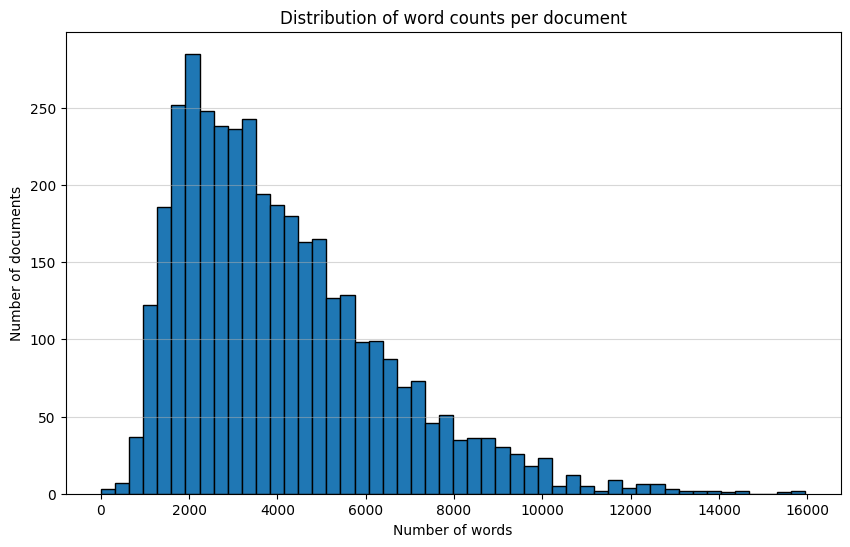

In [ ]:
# Histogram words count
plt.figure(figsize=(10, 6))
plt.hist(dataset["Word_Count"], bins=50, edgecolor="black")
plt.title("Distribution of word counts per document")
plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.grid(axis="y", alpha=0.5)
plt.show()

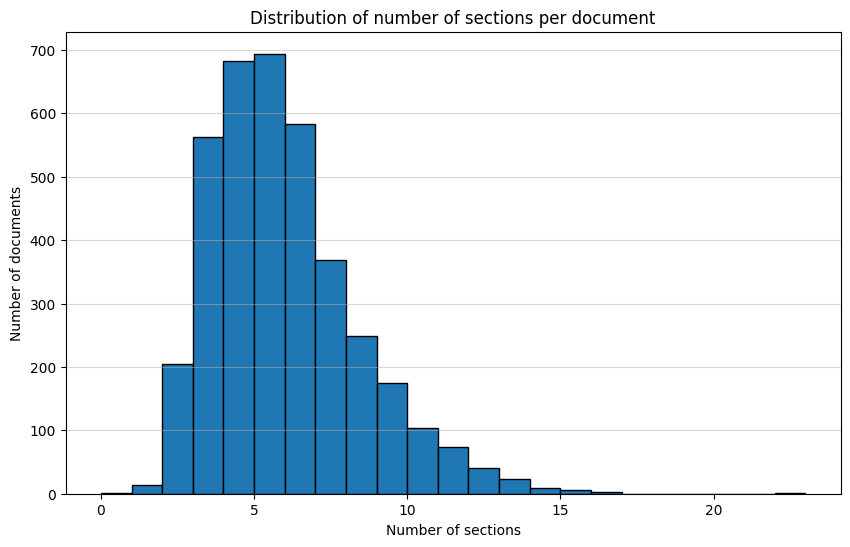

In [ ]:
# Histogram sections count
plt.figure(figsize=(10, 6))
plt.hist(dataset["Num_Sections"], bins=max(dataset["Num_Sections"]), edgecolor="black")
plt.title("Distribution of number of sections per document")
plt.xlabel("Number of sections")
plt.ylabel("Number of documents")
plt.xticks(range(0, max(dataset["Num_Sections"]), 5))
plt.grid(axis="y", alpha=0.5)
plt.show()

# General Pre-processing
Since our data were taken from Wikipedia, there can be, for both the "Full_Text" and the "Summary", citation markers: [i], [p], [1], [j],...
We need to remove these markers since they don't carry any kind of information.

Also, since our aim is to perform text summarization, we will also correct non-ASCII characters, spaces before punctuation, normalize white spaces and backslash

In [ ]:
def general_preprocessing(text):
  """
  Clean text data.
  """
  # Remove html and decode symbols ("&amp" -> "&")
  soup = BeautifulSoup(text, "html.parser")
  text = soup.get_text(separator=" ")

  # Remove Wikipedia citations [1], [p], ...
  text = re.sub(r'\[.*?\]', '', text)

  # Remove non-ASCII characters
  text = re.sub(r'[^\x00-\x7F]+', ' ', text)

  # Fix space before puntuation ("hello ." -> "hello.")
  text = re.sub(r'\s+([.,;:!?])', r'\1', text)

  # Normalize white spaces ("hello     cat" -> "hello cat")
  text = re.sub(r'\s+', ' ', text).strip()

  # Backslash "\'"
  text = re.sub(r"\\'", "'", text)

  return text

In [ ]:
# Applying the pre-processing

dataset["Full_Text"] = dataset["Full_Text"].apply(general_preprocessing)
dataset["Summary"] = dataset["Summary"].apply(general_preprocessing)

In [ ]:
print(dataset["Summary"].iloc[0])

Control is the third studio album by American recording artist Janet Jackson, released on February 4, 1986 by A&M Records. Her collaborations with songwriters and record producers Jimmy Jam and Terry Lewis resulted in an unconventional sound: a fusion of rhythm and blues, funk, disco, rap vocals, and synthesized percussion that established Jackson, Jam and Lewis as the leading innovators of contemporary R&B. It enabled Jackson to transition into the popular music market, becoming one of the defining albums of the 1980s and contemporary music. Containing autobiographical themes, a majority of the album's lyrics came as the result of a series of changes in her life: a recent annulment from R&B singer James DeBarge, severing her business affairs from her father and manager Joseph and the rest of the Jackson family, hiring A&M executive John McClain as her new management, and her subsequent introduction to Jam and Lewis. The album has been praised by critics as both an artistic feat and as

# Topic Modeling

## pLSA & LDA

Probabilistic models such as pLSA (NMF) and LDA rely on statistical word counts. Since these models treat documents as unordered collections of words, they are highly sensitive to noise and vocabulary size.

Therefore, to reduce sparsity and enhance performance, we apply this preprocessing pipeline:

*   Lowercase
*   Tokenization
*   Remove puntuation
*   Stopword
*   Lemmatization
*   Bigrams & Trigrams

In [ ]:
nltk.download('punkt')              # tokenizer
nltk.download('punkt_tab')          # tokenizer
nltk.download('stopwords')          # Stopwords
nltk.download('wordnet')            # Lemma words

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def plsa_lda_preprocessing(text):

  # 1. Lowercase ("Hello" -> "hello")
  text = text.lower()

  # 2. Tokenization ("hello!" -> "hello", "!")
  tokens = nltk.word_tokenize(text)

  # 3. and 4. Remove punctuation and stopwords
  clean_tokens = []
  for word in tokens:
    if word.isalnum() and word not in stop_words:     # Only alphanumeric tokens and those that are not in the stopwords list can go on

      # 5. Lemmatization ("playing" -> "play")
      lemma = lemmatizer.lemmatize(word)
      clean_tokens.append(lemma)

  return clean_tokens

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Applying plsa and lda pre-processing

dataset["tokens_plsa_lda"] = dataset["Full_Text"].apply(plsa_lda_preprocessing)

In [ ]:
dataset["tokens_plsa_lda"]

,tokens_plsa_lda
0,"[jackson, message, fan, booklet, like, thank, ..."
1,"[ernest, shackleton, born, 15, february, 1874,..."
2,"[president, paul, von, hindenburg, appointed, ..."
3,"[lombard, king, wacho, migrated, towards, east..."
4,"[season, officially, began, june, 15, ended, n..."
...,...
3788,"[michigan, constitution, 1850, called, creatio..."
3789,"[process, founding, order, canada, began, earl..."
3790,"[turn, 20th, century, southern, california, ma..."
3791,"[recorded, history, taiwanese, aborigine, defi..."


In [ ]:
dataset["tokens_plsa_lda"].iloc[0][:50]

['jackson',
 'message',
 'fan',
 'booklet',
 'like',
 'thank',
 'everyone',
 'involved',
 'album',
 'special',
 'thanks',
 'joe',
 'jackson',
 'production',
 'special',
 'thanks',
 'john',
 'mcclain',
 'giving',
 'inspiration',
 'drive',
 'anything',
 'want',
 'needed',
 'love',
 'special',
 'thanks',
 'mother',
 'loving',
 'sticking',
 'side',
 'project',
 'matter',
 'decided',
 'love',
 'much',
 'mother',
 'special',
 'thanks',
 'jimmy',
 'terry',
 'making',
 'album',
 'great',
 'experience',
 'helping',
 'express',
 'way',
 'feel',
 'album']

In [ ]:
# Bigrams

bigram = gensim.models.Phrases(dataset['tokens_plsa_lda'], threshold=10)
dataset['Bigrams'] = [bigram[line] for line in dataset['tokens_plsa_lda']]

dataset['Bigrams'][0]

['jackson',
 'message',
 'fan',
 'booklet',
 'like',
 'thank',
 'everyone',
 'involved',
 'album',
 'special',
 'thanks',
 'joe',
 'jackson',
 'production',
 'special',
 'thanks',
 'john_mcclain',
 'giving',
 'inspiration',
 'drive',
 'anything',
 'want',
 'needed',
 'love',
 'special',
 'thanks',
 'mother',
 'loving',
 'sticking',
 'side',
 'project',
 'matter',
 'decided',
 'love',
 'much',
 'mother',
 'special',
 'thanks',
 'jimmy',
 'terry',
 'making',
 'album',
 'great',
 'experience',
 'helping',
 'express',
 'way',
 'feel',
 'album',
 'showing',
 'melanie',
 'great',
 'fun',
 'working',
 'project',
 'miss',
 'guy',
 'much',
 'love',
 'jan',
 'joseph',
 'jackson',
 'patriarch',
 'jackson',
 'family',
 'musician',
 'known',
 'managing',
 'career',
 'nine',
 'child',
 'notably',
 'successful_career',
 'jackson',
 'arranging',
 'recording',
 'contact',
 '1982',
 'janet',
 'oversaw',
 'entire',
 'production',
 'debut_album',
 'janet_jackson',
 'dream',
 'street',
 '1984',
 'latter',


In [ ]:
# Trigrams

trigram = gensim.models.Phrases(dataset['Bigrams'], threshold=10)   # Perform trigrams on bigrams
dataset['tokens_plsa_lda'] = [trigram[line] for line in dataset['Bigrams']]

dataset['tokens_plsa_lda'][1]  # This column now has all the single tokens, the bigrams and the trigrams

['ernest_shackleton',
 'born',
 '15_february',
 '1874',
 'kilkea',
 'near',
 'athy',
 'county_kildare',
 'ireland',
 '46',
 'mile',
 '74_km',
 'dublin',
 'ernest',
 'father',
 'henry',
 'shackleton',
 'mother',
 'henrietta',
 'letitia',
 'sophia',
 'gavan',
 'father',
 'family',
 'originally',
 'yorkshire_england',
 'mother',
 'family',
 'irish',
 'county_cork',
 'kerry',
 'ernest',
 'second',
 'ten_child',
 'first',
 'two',
 'son',
 'second',
 'frank',
 'achieved_notoriety',
 'suspect',
 'later',
 'exonerated',
 '1907',
 'theft',
 'ireland',
 'crown_jewel',
 '1880',
 'ernest',
 'six',
 'henry',
 'shackleton',
 'gave',
 'life',
 'landowner',
 'study_medicine',
 'trinity_college_dublin',
 'moving',
 'family',
 'city',
 'four_year_later',
 'family_moved',
 'ireland',
 'sydenham',
 'suburban',
 'london',
 'partly',
 'search',
 'better',
 'professional',
 'prospect',
 'newly',
 'qualified',
 'doctor',
 'another_factor',
 'may',
 'unease',
 'ancestry',
 'following_assassination',
 'irish_na

In [ ]:
# We don't need the bigrams column anymore

dataset = dataset.drop(columns=["Bigrams"])

In [ ]:
dataset

,Title,Summary,Section Headers,Full_Text,Word_Count,Num_Sections,tokens_plsa_lda
0,Control (Janet Jackson album),Control is the third studio album by American ...,"[Background, Composition and production, Relea...","Jackson's message to the fans in booklet: ""I'd...",3489,7,"[jackson, message, fan, booklet, like, thank, ..."
1,Ernest Shackleton,"Sir Ernest Henry Shackleton, CVO, OBE, FRGS (/...","[Early life, Discovery Expedition, 1901–03, Be...",Ernest Shackleton was born on 15 February 1874...,6299,9,"[ernest_shackleton, born, 15_february, 1874, k..."
2,Night of the Long Knives,The Night of the Long Knives (German: Nacht de...,"[Hitler and the Sturmabteilung (SA), Conflict ...",President Paul von Hindenburg appointed Hitler...,5232,5,"[president, paul_von_hindenburg, appointed, hi..."
3,Alboin,"Alboin (530s June 28, 572) was king of the Lom...","[Father's rule, Reign in Pannonia, Preparation...",The Lombards under King Wacho had migrated tow...,4860,6,"[lombard, king, wacho, migrated, towards, east..."
4,1950 Atlantic hurricane season,The 1950 Atlantic hurricane season was the fir...,"[Summary, Storms, Storm names]",The season officially began on June 15 and end...,3314,3,"[season, officially, began, june_15, ended, no..."
...,...,...,...,...,...,...,...
3788,History of Michigan State University,The history of Michigan State University (MSU)...,"[Agriculture school, Civil War and post-war pe...",The Michigan Constitution of 1850 called for t...,2929,5,"[michigan_constitution, 1850, called, creation..."
3789,Order of Canada,The Order of Canada (French: Ordre du Canada) ...,"[Creation, Grades, Insignia, Eligibility and a...",The process of founding the Order of Canada be...,3314,5,"[process, founding, order_canada, began, early..."
3790,"University of California, Riverside","The University of California, Riverside, commo...","[History, Campus, Academics, Student life, Alu...","At the turn of the 20th century, Southern Cali...",4733,5,"[turn_20th_century, southern_california, major..."
3791,Taiwanese aborigines,Recognized AmisAtayalBununKavalanPaiwanPuyumaR...,"[History and tribal definitions, Recognized pe...","For most of their recorded history, Taiwanese ...",9196,5,"[recorded_history, taiwanese_aborigine, define..."


In [ ]:
 # Recompose the pre-processed document to feed them to the models

documents=dataset["tokens_plsa_lda"].apply(lambda x: " ".join(x))   # Every token next to each other
print(documents)

0       jackson message fan booklet like thank everyon...
1       ernest_shackleton born 15_february 1874 kilkea...
2       president paul_von_hindenburg appointed hitler...
3       lombard king wacho migrated towards east panno...
4       season officially began june_15 ended november...
                              ...                        
3788    michigan_constitution 1850 called creation agr...
3789    process founding order_canada began early 1966...
3790    turn_20th_century southern_california major pr...
3791    recorded_history taiwanese_aborigine defined a...
3792    may 1907 conference germany navy_office decide...
Name: tokens_plsa_lda, Length: 3793, dtype: object


In [ ]:
# Mapping every word into a dictionar

tokenized_docs = dataset["tokens_plsa_lda"].tolist()
dictionary = Dictionary(tokenized_docs)

pLSA & LDA are sensitive to the choice of the parameters and the number of topics.

These are our results:

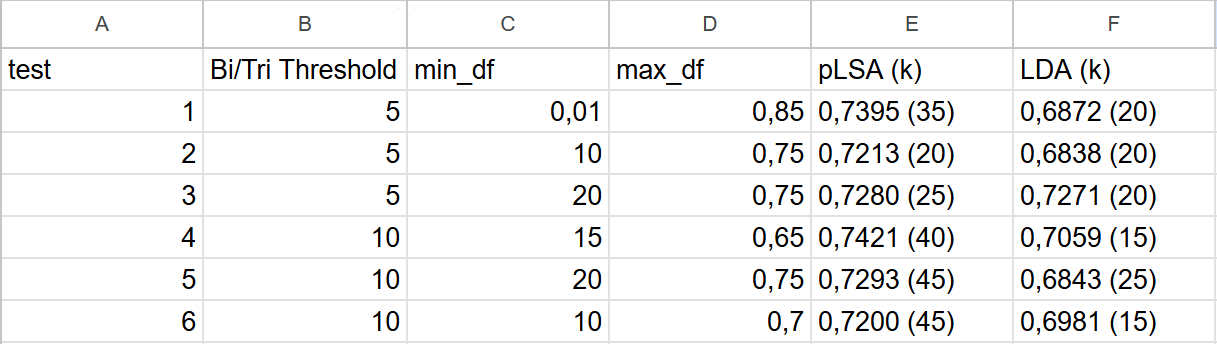
Since we found that our best model is the pLSA in all the experiments, we decided to focus on this model. This is the reseaon that the bigrams and trigrams are built with a threshold = 10.

In [ ]:
# Number of possible topics
k_values = [2,5,10,15,20,25,30,35,40,45,50]

pLSA

In [ ]:
# Storage
plsa_errors = []
plsa_coherence = []

# Document-topic matrices
plsa_doc_topic = {}

# Tf-idf
tfidf_vectorizer = TfidfVectorizer(stop_words="english",
                                   min_df=15,      # ignores terms that appear less than 15 times
                                   max_df=0.65)    # ignores terms that appear in more than 65%

tfidf = tfidf_vectorizer.fit_transform(documents)
terms_tfidf = tfidf_vectorizer.get_feature_names_out()

for k in tqdm(k_values):
    print(f"\nTesting pLSA (NMF KL) with k = {k}")

    nmf = NMF(
        n_components=k,
        random_state=42,
        beta_loss="kullback-leibler",
        solver="mu",
        init="nndsvda",
        max_iter=200
    )

    W = nmf.fit_transform(tfidf)
    H = nmf.components_
    plsa_errors.append(nmf.reconstruction_err_)

    # Most important topics
    topics_list = []
    for topic in H:
        top_indices = topic.argsort()[:-11:-1]      # We take the first 10 words from each topic
        top_words = [terms_tfidf[i] for i in top_indices]
        topics_list.append(top_words)

    # Coherence
    cm = CoherenceModel(
        topics=topics_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    plsa_coherence.append(score)



    print(f"  Reconstruction error = {nmf.reconstruction_err_:.4f}")

    plsa_doc_topic[k] = W

    # Top 5 termini per topic
    for i, topic in enumerate(H):
        top_terms = sorted([(terms_tfidf[j], topic[j]) for j in range(len(topic))], key=lambda x: -x[1])[:5]
        print(f"    Topic {i+1}: {', '.join([t[0] for t in top_terms])}")

  0%|          | 0/11 [00:00<?, ?it/s]


Testing pLSA (NMF KL) with k = 2


  9%|▉         | 1/11 [02:24<24:00, 144.09s/it]

  Reconstruction error = 617.2703
    Topic 1: specie, ship, area, island, building
    Topic 2: game, film, album, song, player

Testing pLSA (NMF KL) with k = 5
  Reconstruction error = 589.1989
    Topic 1: king, building, city, state, government
    Topic 2: game, team, player, season, club
    Topic 3: album, film, song, band, music
    Topic 4: specie, bird, animal, population, specimen


 18%|█▊        | 2/11 [05:18<24:17, 162.00s/it]

...

    Topic 39: german, government, soviet, germany, jew
    Topic 40: painting, artist, art, photograph, portrait

Testing pLSA (NMF KL) with k = 45
  Reconstruction error = 516.2997
    Topic 1: wrote, life, father, book, child
    Topic 2: game, player, character, gameplay, video_game
    Topic 3: album, song, band, music, lyric
    Topic 4: specie, bird, nest, male, female
    Topic 5: ship, battleship, fleet, gun, navy
    Topic 6: storm, hurricane, tropical_storm, wind, cyclone
    Topic 7: film, episode, character, series, movie
    Topic 8: club, match, team, season, player
    Topic 9: park, area, creek, town, lake
    Topic 10: army, german, battle, french, troop
    Topic 11: star, planet, earth, orbit, sun
    Topic 12: mushroom, fruit_body, specie, spore, fungus
    Topic 13: castle, king, bishop, henry, england
    Topic 14: australian, raaf, australia, squadron, melbourne
    Topic 15: flag, national_flag, belarusian, belarus, lithuania
    Topic 16: building, house, room,

 91%|█████████ | 10/11 [51:46<06:57, 417.78s/it]

    Topic 44: saigon, diem, coup, government, vietnam
    Topic 45: church, jew, jewish, congregation, hitler

Testing pLSA (NMF KL) with k = 50
  Reconstruction error = 512.4132
    Topic 1: book, idea, life, wrote, science
    Topic 2: game, player, character, gameplay, video_game
    Topic 3: album, song, band, music, lyric
    Topic 4: specie, bird, nest, male, female
    Topic 5: ship, battleship, gun, fleet, navy
    Topic 6: storm, hurricane, tropical_storm, wind, cyclone
    Topic 7: film, episode, character, series, movie
    Topic 8: club, match, team, season, player
    Topic 9: park, creek, lake, dam, trail
    Topic 10: army, battalion, division, german, force
    Topic 11: element, electron, galaxy, atom, gas
    Topic 12: mushroom, fruit_body, specie, spore, fungus
    Topic 13: castle, king, bishop, henry, england
    Topic 14: raaf, australian, squadron, australia, aircraft
    Topic 15: flag, national_flag, belarusian, belarus, coat_arm
    Topic 16: building, house, 

100%|██████████| 11/11 [1:00:32<00:00, 330.21s/it]

    Topic 47: jackson, photograph, shark, everglades, waugh
    Topic 48: chicago, city, park, millennium_park, pavilion
    Topic 49: planet, star, orbit, sun, earth
    Topic 50: german, soviet, germany, polish, russian


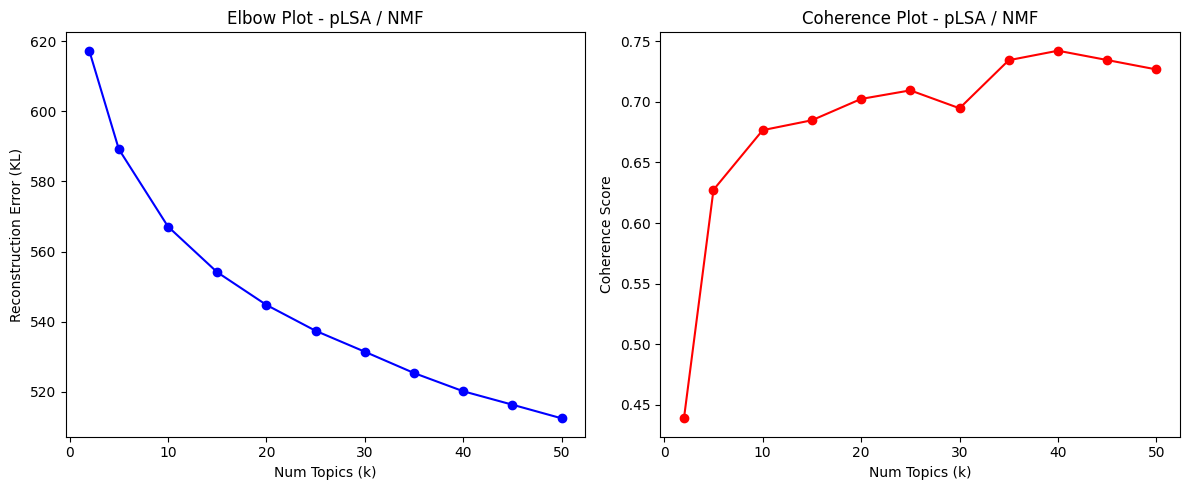

In [ ]:
# Reconstruction Error
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, plsa_errors, marker='o', color='blue')
plt.xlabel("Num Topics (k)")
plt.ylabel("Reconstruction Error (KL)")
plt.title("Elbow Plot - pLSA / NMF")

# Coherence Score
plt.subplot(1, 2, 2)
plt.plot(k_values, plsa_coherence, marker='o', color='red')
plt.xlabel("Num Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Coherence Plot - pLSA / NMF")

plt.tight_layout()
plt.show()

In [ ]:
# pLSA results

max_plsa_coherence = max(plsa_coherence)
max_plsa_coherence_index = plsa_coherence.index(max_plsa_coherence)
k_for_max_plsa_coherence = k_values[max_plsa_coherence_index]

print(f"Maximum pLSA Coherence Score: {max_plsa_coherence:.4f}")
print(f"Corresponding k value for max pLSA Coherence: {k_for_max_plsa_coherence}")

Maximum pLSA Coherence Score: 0.7421
Corresponding k value for max pLSA Coherence: 40


LDA

In [ ]:
# Storing
lda_perplexities = []
lda_coherence = []

# Document-topic matrices
lda_doc_topic = {}

# Countvectorizer
count_vectorizer = CountVectorizer(stop_words="english",
                                   min_df=10,
                                   max_df=0.70
                                   )

tf = count_vectorizer.fit_transform(documents)
terms_count = count_vectorizer.get_feature_names_out()

for k in tqdm(k_values):
    print(f"\nTesting LDA with k = {k}")

    lda = LatentDirichletAllocation(
        n_components=k,
        max_iter=100,
        learning_method="online",
        random_state=42
    )

    lda.fit(tf)


    lda_doc_topic[k] = lda.transform(tf)
    topics_lda = []

    # Most important topics
    for i, topic in enumerate(lda.components_):
        top_terms = sorted([(terms_count[j], topic[j]) for j in range(len(topic))], key=lambda x: -x[1])[:5]
        print(f"    Topic {i+1}: {', '.join([t[0] for t in top_terms])}")
        topics_lda.append([t[0] for t in top_terms])

    # coherence
    cm = CoherenceModel(
        topics=topics_lda,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    score = cm.get_coherence()
    lda_coherence.append(score)

    perplexity = lda.perplexity(tf)
    lda_perplexities.append(perplexity)
    print(f"  Perplexity = {perplexity:.4f}")


lda_max=max(lda_coherence)

  0%|          | 0/11 [00:00<?, ?it/s]


Testing LDA with k = 2
    Topic 1: game, work, film, team, ship
    Topic 2: area, specie, known, building, city


  9%|▉         | 1/11 [06:32<1:05:20, 392.04s/it]

  Perplexity = 11151.9425

Testing LDA with k = 5
    Topic 1: game, film, team, song, player
    Topic 2: work, king, state, government, book
    Topic 3: specie, form, known, bird, animal
    Topic 4: city, building, area, park, built
    Topic 5: ship, force, attack, battle, german


 18%|█▊        | 2/11 [16:05<1:14:48, 498.74s/it]

...

  Perplexity = 7320.3608

Testing LDA with k = 45
    Topic 1: building, work, design, temple, stone
    Topic 2: king, church, england, castle, john
    Topic 3: brook, kerry, film, team, work
    Topic 4: olga, nicholas, nurse, ayres, alexei
    Topic 5: building, ship, minneapolis, city, work
    Topic 6: arthur, canberra, jennings, kink, act
    Topic 7: cell, protein, disease, treatment, patient
    Topic 8: race, car, plant, brown, flower
    Topic 9: city, area, park, road, river
    Topic 10: army_group, arthur, bird, specie, german
    Topic 11: king, queen, parliament, edward, george
    Topic 12: state, government, president, member, student
    Topic 13: canada, indian, boston, fort, american
    Topic 14: lion, punk, cub, zoo, punk_rock
    Topic 15: run, match, england, australia, bradman
    Topic 16: bowie, belgrade, berg, beckham, bragg
    Topic 17: form, example, number, use, group
    Topic 18: ship, expedition, island, scott, crew
    Topic 19: lancaster, sharpe, m

 91%|█████████ | 10/11 [3:00:41<24:34, 1474.25s/it]

  Perplexity = 7286.5502

Testing LDA with k = 50
    Topic 1: temple, flag, king, roman, emperor
    Topic 2: race, issue, magazine, car, story
    Topic 3: film, delius, work, welding, team
    Topic 4: olga, tsar, nicholas, alexei, alexandra
    Topic 5: ship, gun, battleship, navy, carrier
    Topic 6: song, album, band, music, record
    Topic 7: form, cell, example, protein, group
    Topic 8: plant, brown, specie, flower, seed
    Topic 9: area, city, park, road, river
    Topic 10: specie, bird, arthur, male, lion
    Topic 11: king, william, queen, henry, edward
    Topic 12: state, government, member, school, president
    Topic 13: run, match, england, australia, bradman
    Topic 14: texas, spanish, slave, spain, puerto_rico
    Topic 15: australia, tchaikovsky, minneapolis, city, shackleton
    Topic 16: berg, city_college, school, student, baltimore
    Topic 17: known, use, form, period, number
    Topic 18: ship, island, crew, captain, boat
    Topic 19: lancaster, shar

100%|██████████| 11/11 [3:33:40<00:00, 1165.48s/it]

  Perplexity = 7204.1232


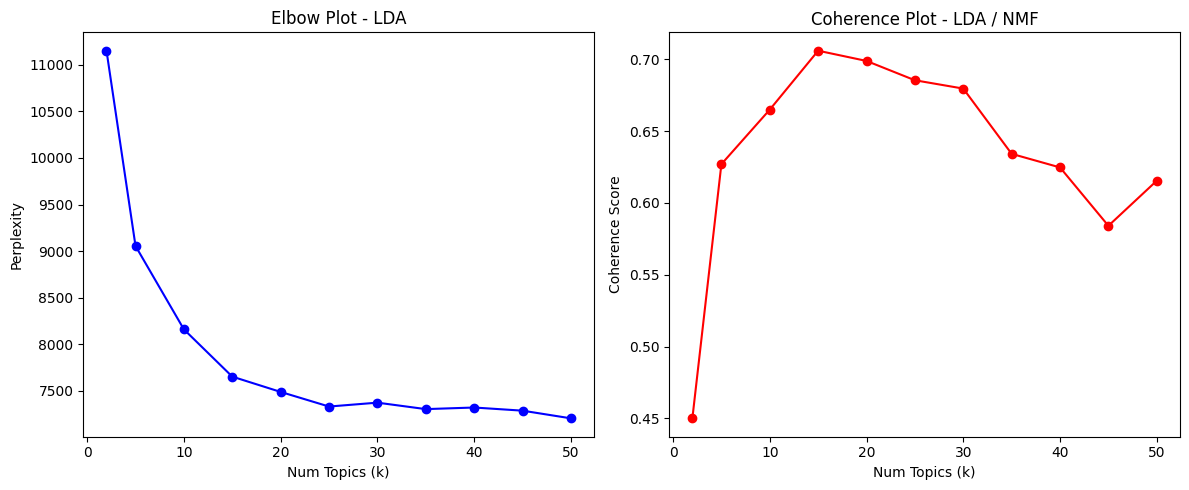

In [ ]:
# Reconstruction Error
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, lda_perplexities, marker='o', color='blue')
plt.xlabel("Num Topics (k)")
plt.ylabel("Perplexity")
plt.title("Elbow Plot - LDA")

# Coherence Score
plt.subplot(1, 2, 2)
plt.plot(k_values, lda_coherence, marker='o', color='red')
plt.xlabel("Num Topics (k)")
plt.ylabel("Coherence Score")
plt.title("Coherence Plot - LDA / NMF")

plt.tight_layout()
plt.show()

In [ ]:
max_lda_coherence = max(lda_coherence)
max_lda_coherence_index = lda_coherence.index(max_lda_coherence)
k_for_max_lda_coherence = k_values[max_lda_coherence_index]

print(f"Maximum LDA Coherence Score: {max_lda_coherence:.4f}")
print(f"Corresponding k value for max LDA Coherence: {k_for_max_lda_coherence}")

Maximum LDA Coherence Score: 0.7059
Corresponding k value for max LDA Coherence: 15


## BERTopic

In [ ]:
# We need to use a GPU to perform BERTopic

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
list_bert = dataset["Full_Text"].tolist()
tokenized_full = [doc.lower().split() for doc in list_bert]  # tokenization
dictionary_bert = Dictionary(tokenized_full)

In [ ]:
docs_for_bertopic = documents.tolist()

In [ ]:
print(list_bert[0][:200])
print("\n")
print(tokenized_full[0][:200])

Jackson's message to the fans in booklet: "I'd like to thank everyone who was involved with this album. Special thanks to Joe Jackson Productions. A very special thanks to John McClain for giving me t


["jackson's", 'message', 'to', 'the', 'fans', 'in', 'booklet:', '"i\'d', 'like', 'to', 'thank', 'everyone', 'who', 'was', 'involved', 'with', 'this', 'album.', 'special', 'thanks', 'to', 'joe', 'jackson', 'productions.', 'a', 'very', 'special', 'thanks', 'to', 'john', 'mcclain', 'for', 'giving', 'me', 'the', 'inspiration', 'and', 'drive', 'to', 'do', 'anything', 'i', 'want,', 'and', 'for', 'being', 'there', 'when', 'i', 'needed', 'him', 'the', 'most.', 'i', 'love', 'you.', 'a', 'special', 'thanks', 'to', 'mother', 'for', 'loving', 'me,', 'and', 'for', 'sticking', 'by', 'my', 'side', 'through', 'this', 'project', 'no', 'matter', 'what', 'it', 'was', 'i', 'had', 'decided', 'to', 'do.', 'i', 'love', 'you', 'very', 'much,', 'mother.', 'and', 'a', 'very', 'special', 'thanks', 'to', 'jimmy', 

To perform BERTopic we first need a SentenceTransform model to extract the embeddings.
Since our documents can be long, we preferred not to split the text into chunks (where the model can lose track of the whole topic of text),
but we decided to use "jina-embeddings-v2-small-en": a model with a context of 8192 tokens.

In [ ]:
# SentenceTransformer model initialization

embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v2-small-en",
    trust_remote_code=True,
    device=device,
    model_kwargs={"torch_dtype": torch.float16}
)

embedding_model.max_seq_length = 8192

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Embedding extraction

embedding=embedding_model.encode(list_bert,
                                 batch_size=2,
                                 show_progress_bar=True)

Batches:   0%|          | 0/1897 [00:00<?, ?it/s]

In [ ]:
np.save("embedding.npy", embedding)

In [ ]:
# To download the extracted embeddings, use
# embedding=np.load("/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/embedding.npy")

Now that we have extracted the embeddings, we can perform BERTopic. To enhance its quality, we can set different settings:
*   UMAP
*   HDBSCAN
*   Vectorizer
*   cTfidf_model

In [ ]:
# UMAP: dimensionality reduction.
# As embeddings are often high in dimensionality, clustering becomes difficult due to the curse of dimensionality.

umap_model = UMAP(n_neighbors=25,
                  n_components=5,
                  min_dist=0.0,
                  metric='cosine',
                  random_state=42)

In [ ]:
# HDBSCAN: cluster input embeddings into groups of similar embeddings to extract our topics

hdbscan_model=hdbscan.HDBSCAN(min_cluster_size=40,
                      metric="euclidean",
                      cluster_selection_method='eom',
                      prediction_data=True)

In [ ]:
# Vectorizer: enhance topic quality

vectorizer_model=CountVectorizer(stop_words="english",
                                 max_df=0.85,
                                 min_df=15,
                                 ngram_range=(1,2)
                                 )

In [ ]:
# c-TF-IDF: class-based TF-IDF procedure
# BM25-inspired idf-weighting procedure instead of the procedure as defined in the c-TF-IDF formula. It uses the following weighting scheme: log(1+((avg_nr_samples - df + 0.5) / (df+0.5)))

ctfidf_model = ClassTfidfTransformer(bm25_weighting=True)

In [ ]:
# BERTopic definition

topic_model = BERTopic(embedding_model=embedding_model,
                       hdbscan_model=hdbscan_model,
                       umap_model=umap_model,
                       representation_model=None,
                       ctfidf_model=ctfidf_model,
                       vectorizer_model=vectorizer_model,
                       verbose=True)

In [ ]:
# BERTopic fit

topics, probs = topic_model.fit_transform(documents=dataset["Full_Text"],
                                          embeddings=embedding
                                          )

2025-12-30 17:37:10,976 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-30 17:37:47,103 - BERTopic - Dimensionality - Completed ✓
2025-12-30 17:37:47,104 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-30 17:37:47,240 - BERTopic - Cluster - Completed ✓
2025-12-30 17:37:47,245 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-30 17:38:10,812 - BERTopic - Representation - Completed ✓


### BERTopic Graph

In [ ]:
topic_model.visualize_topics()

In [ ]:
topic_model.visualize_barchart()

In [ ]:
topic_model.visualize_heatmap()

### BERTopic Coherence

In [ ]:
topic_list_bert = topic_model.get_topics()

print("Outlier Topic (-1):")
print(topic_list_bert[-1])
print("\nTopic 0:")
print(topic_list_bert[0])
print("\nTopic 1:")
print(topic_list_bert[1])

Outlier Topic (-1):
[('expedition', np.float64(0.01751289670416864)), ('shakespeare', np.float64(0.01300516449167887)), ('di', np.float64(0.012766140725541292)), ('dynasty', np.float64(0.01247180024034128)), ('vietnam', np.float64(0.011560219717297917)), ('pedro', np.float64(0.011012227673577436)), ('liberal', np.float64(0.010550920547244018)), ('scientific', np.float64(0.01040983330648794)), ('flags', np.float64(0.01032900541356232)), ('bc', np.float64(0.009647041264755385))]

Topic 0:
[('guns', np.float64(0.05602709457384109)), ('fleet', np.float64(0.05330427583404451)), ('infantry', np.float64(0.04192852384364625)), ('gun', np.float64(0.03492783015536518)), ('inch', np.float64(0.029871593665411554)), ('artillery', np.float64(0.028076308479429282)), ('carrier', np.float64(0.02755273480680485)), ('mm', np.float64(0.02727042951658844)), ('deck', np.float64(0.027066532303987912)), ('air force', np.float64(0.026445779999495798))]

Topic 1:
[('creek', np.float64(0.06505590339477692)), ('h

In [ ]:
# Coherence for BERTopic

topics_for_coherence = []
for topic_id, term_scores in topic_list_bert.items(): # Use topic_list_bert, which is a dictionary
    if topic_id == -1: continue    # Remove outliers

    top_terms = [term for term, score in term_scores]
    topics_for_coherence.append(top_terms)

# Coherence
cm = CoherenceModel(
    topics=topics_for_coherence,
    texts=tokenized_docs,   # We have to compare the same texts to keep the comparison fair
    dictionary=dictionary,
    coherence='c_v'
)

score_bert = cm.get_coherence()
print("BERTopic coherence c_v:", score_bert)

BERTopic coherence c_v: 0.6236622461489004


We think that the coherence of BERTopic appears low compared to the other models not due to poor model performance, but rather a problem in the evaluation methodology.

The coherence was calculated using the reference dictionary optimized for pLSA and its tokens. However, BERTopic, operates in raw text to leverage transformer embeddings. Consequently, perfectly valid semantic topics identified by BERTopic fail to match.

In [ ]:
# Save RAM

del topic_model
del embedding_model
clean_memory()

## Topic Modeling evalutation

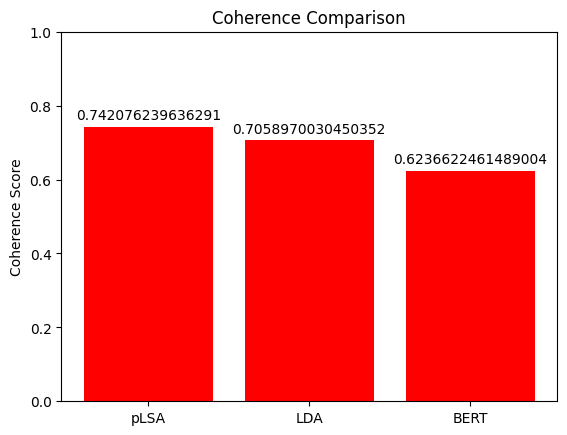

In [ ]:
coherence_scores = [max_plsa_coherence, max_lda_coherence, score_bert]
models = ['pLSA', 'LDA', 'BERT']

plt.bar(models, coherence_scores, color='red')
plt.ylabel("Coherence Score")
plt.title("Coherence Comparison")
plt.ylim(0, 1)

for i, v in enumerate(coherence_scores):
    plt.text(i, v + 0.02, str(v), ha='center')  # value above each bar

plt.show()

We found the BEST model in pLSA.

Let's see it:

In [ ]:
# Training with the best parameter we found and the best number of components

tfidf_vectorizer = TfidfVectorizer(stop_words="english",
                                   min_df=15,
                                   max_df=0.65)

X_train = tfidf_vectorizer.fit_transform(documents) # Documents were obtained from documents=dataset["tokens_plsa_lda"].apply(lambda x: " ".join(x))

best_plsa_model = NMF(
    n_components=k_for_max_plsa_coherence ,
    random_state=42,
    beta_loss="kullback-leibler",
    solver="mu",
    init="nndsvda",
    max_iter=200
)

W_train = best_plsa_model.fit_transform(X_train)
H_train = best_plsa_model.components_

In [ ]:
# Most important terms for each topic found from the pLSA

terms = tfidf_vectorizer.get_feature_names_out()

print("\nTopics:")
for i, component in enumerate(best_plsa_model.components_):
    term_weights = [
        (terms[idx], weight)    # term and its weight
        for idx, weight in enumerate(component)
        if weight > 1e-4    # filter out noise
    ]

    top_terms = sorted(
        term_weights, key=lambda x: -x[1]
    )[:10]     # first 10 term with the highest weight

    print(f"\nTopic {i + 1}:")
    for term, weight in top_terms:
        print(f"  {term}: {weight:.4f}")


Topics:

Topic 1:
  child: 0.3458
  family: 0.3432
  woman: 0.3337
  father: 0.3037
  mother: 0.2713
  wrote: 0.2620
  life: 0.2617
  wife: 0.2425
  death: 0.2410
  friend: 0.2334

Topic 2:
  game: 2.0321
  player: 0.7772
  character: 0.4085
  gameplay: 0.2908
  video_game: 0.2342
  nintendo: 0.2004
  released: 0.1896
  release: 0.1844
  graphic: 0.1740
  feature: 0.1606

Topic 3:
  album: 1.8446
  song: 1.3640
  band: 1.2712
  music: 0.4782
  lyric: 0.3373
  recording: 0.3177
  record: 0.3165
  track: 0.3142
  tour: 0.3098
  sound: 0.2911

Topic 4:
  specie: 1.0513
  bird: 1.0281
  nest: 0.5331
  male: 0.5149
  female: 0.4346
  subspecies: 0.3335
  egg: 0.2933
  population: 0.2901
  feather: 0.2323
  breeding: 0.2258

Topic 5:
  ship: 1.8724
  battleship: 0.6754
  fleet: 0.4468
  gun: 0.4353
  navy: 0.3283
  turret: 0.2670
  crew: 0.2636
  vessel: 0.2567
  british: 0.2414
  squadron: 0.2322

Topic 6:
  storm: 1.2779
  hurricane: 1.0149
  wind: 0.4447
  tropical_storm: 0.4432
  cyclon

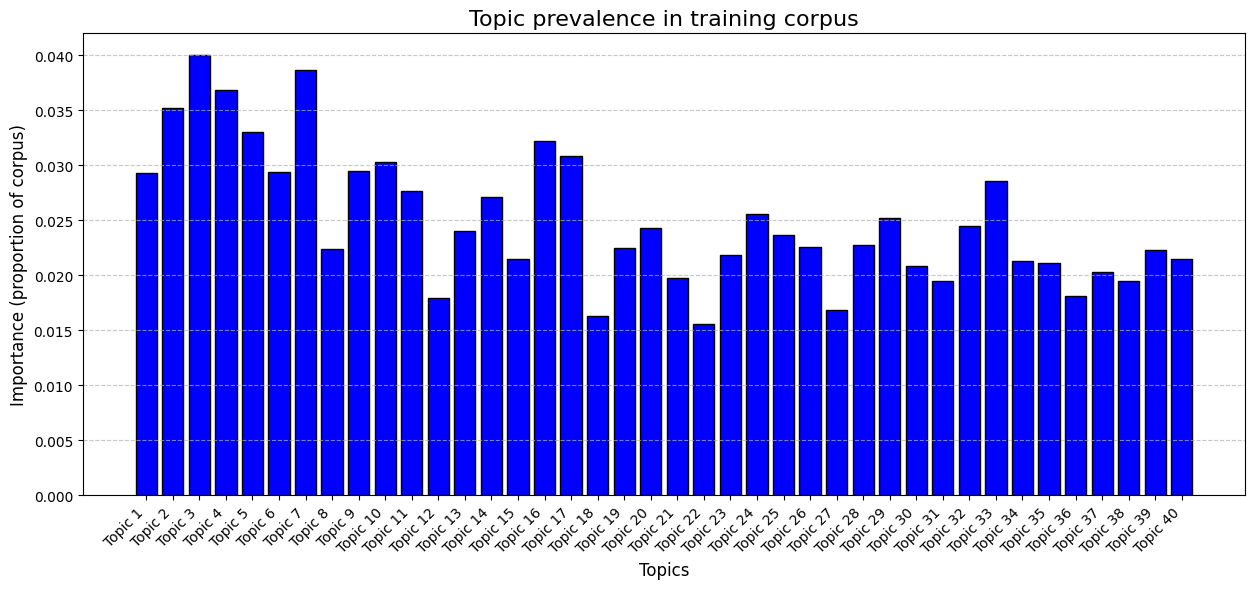

In [ ]:
# Topic prevalence

topic_weights = W_train.sum(axis=0) # average weight of each topic across all documents

topic_weights_norm = topic_weights / topic_weights.sum() # normalize

n_topics = len(topic_weights)
topic_indices = [f"Topic {i+1}" for i in range(n_topics)]

plt.figure(figsize=(15, 6))
plt.bar(topic_indices, topic_weights_norm, color='blue', edgecolor='black')
plt.xlabel('Topics', fontsize=12)
plt.ylabel('Importance (proportion of corpus)', fontsize=12)
plt.title('Topic prevalence in training corpus', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 3793 samples in 0.001s...
[t-SNE] Computed neighbors for 3793 samples in 0.371s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3793
[t-SNE] Computed conditional probabilities for sample 2000 / 3793
[t-SNE] Computed conditional probabilities for sample 3000 / 3793
[t-SNE] Computed conditional probabilities for sample 3793 / 3793
[t-SNE] Mean sigma: 0.025724
[t-SNE] KL divergence after 250 iterations with early exaggeration: 56.743721
[t-SNE] KL divergence after 1000 iterations: 0.427166


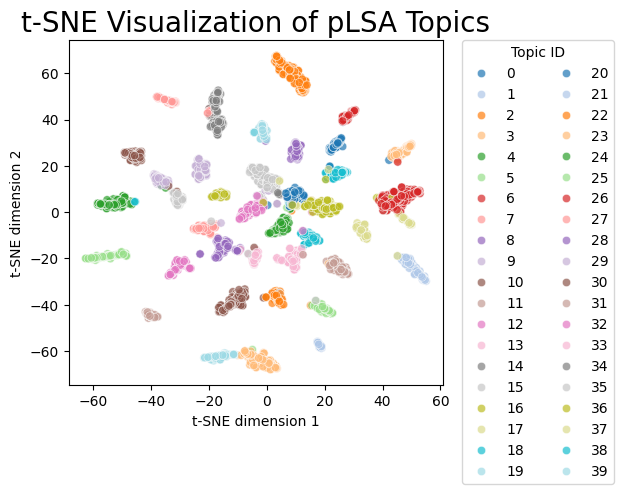

In [ ]:
# Graphical representation through t-SNE

# dominant topic for each document
dominant_topic = np.argmax(W_train, axis=1)

# t-SNE
tsne_model = TSNE(n_components=2,   # reducce the dimensionality of each document from 25 to 2 dimension (so that we can visualize it)
                  verbose=1,
                  perplexity=40,
                  n_iter=1000,
                  random_state=42,
                  init='pca',
                  learning_rate='auto'
                  )

tsne_results = tsne_model.fit_transform(W_train)  # run on the topic distribution

# plot
sns.scatterplot(
    x=tsne_results[:, 0],
    y=tsne_results[:, 1],
    hue=dominant_topic,     # color by topic
    palette="tab20",        # palette with many different colour
    legend="full",
    alpha=0.7               # transparency to see overlapping points
)

plt.title('t-SNE Visualization of pLSA Topics', fontsize=20)
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')

plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0., title="Topic ID", ncol=2)

plt.tight_layout()
plt.show()

# Test set Pre-Process

In [ ]:
test_folder = r"/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/Test Set"

In [ ]:
# Like we did for the training set, we now have to preprocess the test set.

import os
import xml.etree.ElementTree as ET
import pandas as pd

test_rows = []
for document in sorted(os.listdir(test_folder)):
    path = os.path.join(test_folder, document)
    tree = ET.parse(path)
    root = tree.getroot()

    title = root.find("title").text
    # Summary
    summary = " ".join([p.text for p in root.findall("summary/p") if p.text])

    # Body Text
    all_paragraphs = []
    for section in root.findall("body/section"):
        all_paragraphs.extend(find_paragraphs(section))
    full_text = " ".join(all_paragraphs)

    test_rows.append({"Title": title, "Summary": summary, "Full_Text": full_text})

df_test = pd.DataFrame(test_rows)

In [ ]:
df_test

,Title,Summary,Full_Text
0,Jessica Chastain,"Jessica Michelle Chastain (born March 24, 1977...",Jessica Michelle Chastain was born on March 24...
1,Ralph Vaughan Williams,Ralph Vaughan Williams OM (/reɪf vɔːn/ (listen...,"Vaughan Williams was born at Down Ampney, Glou..."
2,William Sterndale Bennett,Sir William Sterndale Bennett (13 April 1816 –...,"Bennett was born in Sheffield, Yorkshire, the ..."
3,Emily Davison,Emily Wilding Davison (11 October 1872�– 8 Jun...,Emily Wilding Davison was born at Roxburgh Hou...
4,Withypool Stone Circle,"Withypool Stone Circle, also known as Withypoo...",Withypool Stone Circle is located on the south...
5,Omayra Sánchez,"Omayra Sánchez Garzón (August 28, 1972�– Novem...","On November 13, 1985, the Nevado del Ruiz volc..."
6,Operation Ironside,Initial Airborne AssaultBritish Sector Americ...,Operation Ironside formed part of Operation Bo...
7,Columbian mammoth,The Columbian mammoth (Mammuthus columbi) is a...,The Columbian mammoth was first scientifically...
8,Charles-Valentin Alkan,Charles-Valentin Alkan[n 1][n 2] (French:�[ʃaʁ...,Alkan was born Charles-Valentin Morhange on 30...
9,Taiwanese indigenous peoples,Nationwide Recognized Locally recognized Unrec...,"For most of their recorded history, Taiwanese ..."


There are 30 documents in the test set.

 Since the extractive summarisation is based on ranking parts of the text, we have split the full text into multiple sentences.

In [ ]:
# Create sentences
df_test["Sentences_Original"] = df_test["Full_Text"].apply(nltk.sent_tokenize)

print(df_test["Sentences_Original"][0])

['Jessica Michelle Chastain was born on March 24, 1977, in Sacramento, California, to Jerri Renee Hastey (née Chastain) and rock musician Michael Monasterio.', 'Her parents were both teenagers when she was born.', 'Chastain is reluctant to publicly discuss her family background; she was estranged from Monasterio, and has said that no father is listed on her birth certificate.', 'She has two sisters and two brothers.', 'Her sister Juliet died by suicide in 2003 following years of drug abuse.', 'Chastain was raised in Sacramento by her mother and stepfather, Michael Hastey, a fire-fighter.', 'She has said that her stepfather was the first person to make her feel secure.', 'She shares a close bond with her maternal grandmother, Marilyn, whom she credits as someone who "always believed in me".', 'Chastain first developed an interest in acting at the age of seven, after her grandmother took her to a production of Joseph and the Amazing Technicolor Dreamcoat.', 'She would regularly put on am

In [ ]:
# We need to perform the SAME preprocessing on the sentences just obtained so that the model can perform correctly

def preprocess_for_inference(sentence_list):
  """
  Preprocess the sentences for inference: general preprocessing and plsa_lda_preprocessing
  """
  cleaned_sentences = []
  for sent in sentence_list:

    text = general_preprocessing(sent)

    tokens = plsa_lda_preprocessing(text)

    # Use the globally defined bigram and trigram models
    tokens_with_phrases = trigram[bigram[tokens]]

    cleaned_sentences.append(" ".join(tokens_with_phrases))
  return cleaned_sentences

df_test["Sentences_Processed"] = df_test["Sentences_Original"].apply(
    lambda x: preprocess_for_inference(x)
)

In [ ]:
print("Original:", df_test["Sentences_Original"].iloc[0][:1])
print("Processed:", df_test["Sentences_Processed"].iloc[0][:1])

Original: ['Jessica Michelle Chastain was born on March 24, 1977, in Sacramento, California, to Jerri Renee Hastey (née Chastain) and rock musician Michael Monasterio.']
Processed: ['jessica michelle chastain born march_24 1977 sacramento_california jerri renee hastey n_e chastain rock_musician michael monasterio']


In [ ]:
# Apply the SAME general preprocessing that we used for the training set (remove: html, decode symbols, citations, non-ASCII. correct: space)

df_test["Summary"]=df_test["Summary"].apply(general_preprocessing)

# Text Summarization

## Extract summarization - Global

In [ ]:
def summarise_docs_extractive_global(
    df,
    processed_col="Sentences_Processed",
    original_col="Sentences_Original",
    tfidf_vectorizer=None,
    best_plsa_model=None,
    num_sentences=7
    ):

    # build summaries
    summaries = []

    # Global H and W
    H_train = best_plsa_model.components_  # topic × vocab
    W_train = best_plsa_model.transform(tfidf_vectorizer.transform(df[processed_col].apply(lambda x: " ".join(x))))  # doc × topic

    # summarisation for each document (row):
    for doc_idx, row in df.iterrows():
        processed_sents = row[processed_col]
        original_sents = row[original_col]

        # check if the document is not empty
        if not processed_sents or len(processed_sents) == 0:
            summaries.append("")
            continue

        # vectorizer trained on train set
        dt_matrix = tfidf_vectorizer.transform(processed_sents)

        # number of topics of the best model (H shape because it has topic on rows)
        n_topics = H_train.shape[0]

        # H is kept the same, W must be shortened to the doc
        W_local_init = np.tile(W_train[doc_idx, :], (len(processed_sents), 1))
        H_local_init = H_train.copy()

        # pLSA with NMF
        local_nmf = NMF(
            n_components=n_topics,
            init="custom",
            beta_loss="kullback-leibler",
            solver="mu",
            max_iter=200,
            random_state=42
        )

        # Matrix with the importance of each sentence of the document for each topic
        W_topics = local_nmf.fit_transform(dt_matrix, W=W_local_init, H=H_local_init)

        # relevance score
        scores = np.sqrt((W_topics ** 2).sum(axis=1))
        scaler = MinMaxScaler()
        relevance_score = scaler.fit_transform(scores.reshape(-1, 1)).flatten()

        # MMR
        selected_indices = []
        candidate_indices = list(range(len(processed_sents)))

        best_idx = np.argmax(relevance_score)
        selected_indices.append(best_idx)
        candidate_indices.remove(best_idx)

        similarity_matrix = cosine_similarity(dt_matrix)

        while len(selected_indices) < min(num_sentences, len(processed_sents)):
            best_mmr_score = -np.inf
            next_best_idx = -1

            for cand_idx in candidate_indices:
                rel = relevance_score[cand_idx]
                sim_to_selected = max(similarity_matrix[cand_idx, selected_indices])
                mmr_score = rel - 0.5 * sim_to_selected
                if mmr_score > best_mmr_score:
                    best_mmr_score = mmr_score
                    next_best_idx = cand_idx

            selected_indices.append(next_best_idx)
            candidate_indices.remove(next_best_idx)

        top_idx = sorted(selected_indices)
        raw_summary = " ".join([original_sents[i] for i in top_idx])
        summaries.append(general_preprocessing(raw_summary))

    # column to the dataframe
    df["summary_global_extractive"] = summaries
    return df

In [ ]:
df_test = summarise_docs_extractive_global(
    df_test,
    processed_col="Sentences_Processed",
    original_col="Sentences_Original",
    tfidf_vectorizer=tfidf_vectorizer,
    best_plsa_model=best_plsa_model,
    num_sentences=7
)

print(df_test["summary_global_extractive"].iloc[0])

The film was screened at the 2011 Sundance Film Festival, and critic Tim Robey of The Daily Telegraph noted how much Chastain's supporting part aided the narrative. Chastain signed on to the film without receiving a traditional screenplay from Malick, and she improvised several scenes and dialogues with Pitt. The film premiered at the 2011 Cannes Film Festival to a polarized reception from the audience, although it was praised by critics and won the Palme d'Or. Chastain's final two roles of the year were in Wilde Salom, a documentary based on her 2006 production of Salome, and the critically panned crime-thriller Texas Killing Fields. She collaborated with costume designer Kasia Walicka-Maimone to work on the character's wardrobe, and contacted Armani who provided her with clothing of the period. Peter Debruge hailed her role as "one of the screen's great female parts" and credited its success to both Chastain's "stratospheric talent" and Sorkin's script. Evgenia Peretz, an editor at V

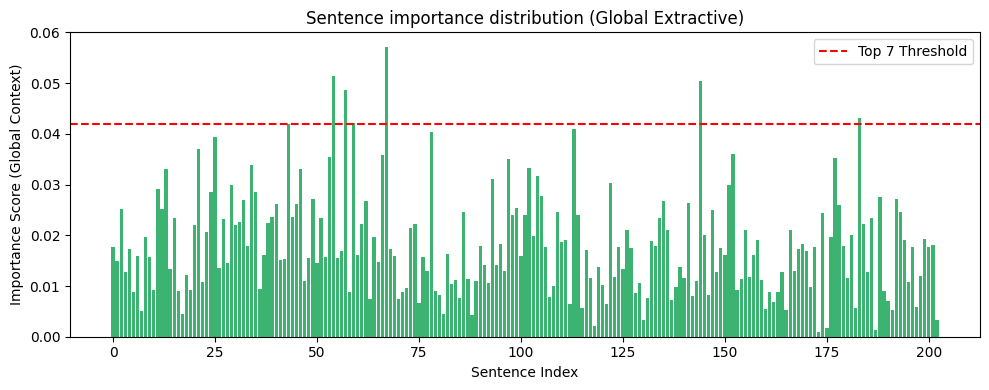

In [ ]:
def plot_global_sentence_scores(processed_sents, original_sents, tfidf_vectorizer, best_plsa_model, num_sentences=7):

    if not processed_sents or len(processed_sents) == 0:
        print("No sentences to plot.")
        return

    # 1. Transform sentences using the GLOBAL vectorizer (not a new one)
    dt_matrix = tfidf_vectorizer.transform(processed_sents)

    # 2. Get Global H and calculate Global W for this specific document
    H_train = best_plsa_model.components_ # topic x vocab

    # We need to calculate the W (Doc x Topic) for this specific document
    # based on the global model to initialize the matrix correctly
    full_doc_as_string = " ".join(processed_sents)
    full_doc_vector = tfidf_vectorizer.transform([full_doc_as_string])

    # Transform this single doc to get its topic distribution based on the global model
    W_doc_global = best_plsa_model.transform(full_doc_vector) # shape (1, n_topics)

    # 3. Initialize matrices exactly like in the global summary function
    # Expand the document's global topic distribution to every sentence row
    W_local_init = np.tile(W_doc_global, (len(processed_sents), 1))
    H_local_init = H_train.copy()

    n_topics = H_train.shape[0]

    # 4. Run NMF with 'custom' init to project sentences onto Global Topics
    local_nmf = NMF(
        n_components=n_topics,
        init="custom",
        beta_loss="kullback-leibler",
        solver="mu",
        max_iter=200,
        random_state=42
    )

    # Calculate sentence importance for each global topic
    W_topics = local_nmf.fit_transform(dt_matrix, W=W_local_init, H=H_local_init)

    # 5. Calculate Scores (Relevance)
    scores = np.sqrt((W_topics ** 2).sum(axis=1))

    # --- PLOTTING ---
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(scores)), scores, color='mediumseagreen') # Different color to distinguish from local
    plt.xlabel('Sentence Index')
    plt.ylabel('Importance Score (Global Context)')
    plt.title('Sentence importance distribution (Global Extractive)')

    # Highlight the threshold for top N sentences
    # (Note: This shows relevance threshold, actual selection uses MMR which might skip some high scores)
    k = min(num_sentences, len(scores))
    if k > 0:
        sorted_scores = sorted(scores)
        threshold = sorted_scores[-k]
        plt.axhline(y=threshold, color='r', linestyle='--', label=f'Top {k} Threshold')
        plt.legend()

    plt.tight_layout()
    plt.show()

# plot
plot_global_sentence_scores(
    processed_sents=df_test["Sentences_Processed"].iloc[0],
    original_sents=df_test["Sentences_Original"].iloc[0],
    tfidf_vectorizer=tfidf_vectorizer,
    best_plsa_model=best_plsa_model,
    num_sentences=7
)


## Extract summatization - Local

In [ ]:
def summarise_docs_extractive_local(processed_sents,
                                    original_sents,
                                    num_sentences=7
                                    ):
    """
    Local Extractive Summarization using pLSA (NMF).
    """

    if not processed_sents or len(processed_sents) == 0:
        return ""

    # Vectorizer (remove min_df/max_df since we are working with set of sentences)
    local_vectorizer = TfidfVectorizer(stop_words="english")

    dt_matrix = local_vectorizer.fit_transform(processed_sents)

    # Number of components (non costant number of topics)
    n_sentences = len(processed_sents)
    if n_sentences < num_sentences:
        k = n_sentences      # If doc is tiny, just take everything
    else:
        # We try to find at least 'num_sentences' topics so we can pick one from each
        k = min(num_sentences + 2, n_sentences)

    # pLSA
    local_nmf = NMF(
        n_components=k,
        random_state=42,
        beta_loss="kullback-leibler",
        solver="mu",
        init="nndsvda",
        max_iter=200
    )

    W_topics = local_nmf.fit_transform(dt_matrix)  # shape: (n_sentences, n_topics)

    # Score Sentences
    scores = np.sqrt((W_topics ** 2).sum(axis=1))  # a higher score means that the sentence is important the dominant topics
    scaler = MinMaxScaler()
    relevance_score = scaler.fit_transform(scores.reshape(-1, 1)).flatten()

    # MMR
    selected_indices = []
    candidate_indices = list(range(len(processed_sents)))
    best_idx = np.argmax(relevance_score)
    selected_indices.append(best_idx)
    candidate_indices.remove(best_idx)

    similarity_matrix = cosine_similarity(dt_matrix)

    while len(selected_indices) < min(num_sentences, len(processed_sents)):
        best_mmr_score = -np.inf
        next_best_idx = -1
        for cand_idx in candidate_indices:
            rel = relevance_score[cand_idx]
            sim_to_selected = np.max(similarity_matrix[cand_idx, selected_indices])
            mmr_score = rel - 0.5 * sim_to_selected # Lambda 0.5
            if mmr_score > best_mmr_score:
                best_mmr_score = mmr_score
                next_best_idx = cand_idx
        selected_indices.append(next_best_idx)
        candidate_indices.remove(next_best_idx)

    # Sort and Join
    top_idx = sorted(selected_indices)
    raw_summary = " ".join([original_sents[i] for i in top_idx])
    return general_preprocessing(raw_summary)

In [ ]:
# Apply to the dataframe
df_test["summary_local_extractive"] = df_test.apply(
    lambda row: summarise_docs_extractive_local(
        row["Sentences_Processed"],   # processed phrases
        row["Sentences_Original"]     # original phrases
    ),
    axis=1
)

In [ ]:
print(df_test["summary_local_extractive"].iloc[0])

Later that year, she appeared as a guest performer on the medical drama series ER playing a woman she described as "psychotic", which led to her getting more unusual parts such as accident victims or the mentally ill. She went on to appear in such roles in a few other television series from 2004 to 2007, including Veronica Mars (2004), Close to Home (2006), Blackbeard (2006), and Law & Order: Trial by Jury (2005 2006). She then starred as the titular character of a depressed woman who separates from her husband (played by James McAvoy) following a tragic incident in the drama The Disappearance of Eleanor Rigby (2013), which she also produced. Hailing her as one of the best actresses on the planet, Peter Travers commended Chastain for successfully drawing the audience into Sloane's life, and writing for Los Angeles Times, Justin Chang called her performance "a tour de force of rhetorical precision and tightly coiled emotional intensity". In the former, an adaptation of Diane Ackerman's 

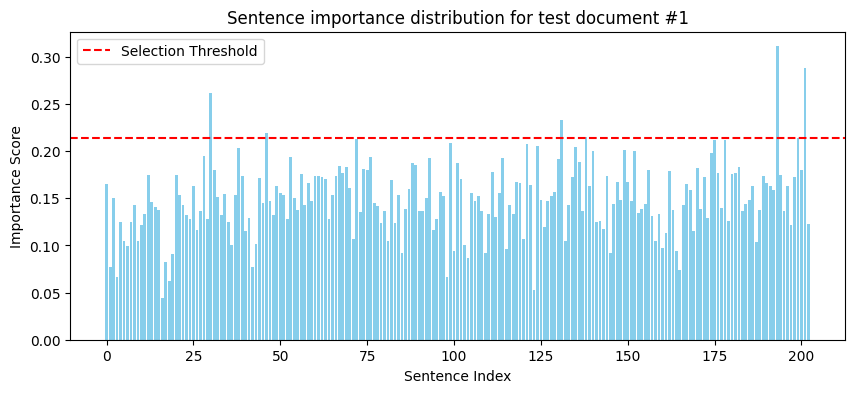

In [ ]:
def plot_local_sentence_scores(processed_sents, original_sents):

    # like before, we initialize the model
    local_vectorizer = TfidfVectorizer(stop_words="english")
    dt_matrix = local_vectorizer.fit_transform(processed_sents)
    local_nmf = NMF(n_components=3, random_state=42, beta_loss="kullback-leibler", solver="mu", init="nndsvda", max_iter=200)
    W_topics = local_nmf.fit_transform(dt_matrix)
    scores = np.sqrt((W_topics ** 2).sum(axis=1))

    # Plot
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(scores)), scores, color='skyblue')
    plt.xlabel('Sentence Index')
    plt.ylabel('Importance Score')
    plt.title('Sentence importance distribution for test document #1')

    # Highlight the top sentences selected
    k = min(7, len(scores))
    threshold = sorted(scores)[-k]
    plt.axhline(y=threshold, color='r', linestyle='--', label='Selection Threshold')
    plt.legend()
    plt.show()

# Visualize the first document in the test set
plot_local_sentence_scores(df_test["Sentences_Processed"].iloc[0], df_test["Sentences_Original"].iloc[0])

## Abstract summarization

### Longformer Encoder-Decoder (LED)

To perform abstractive approach, we utilize the Longformer Encoder-Decoder (LED), a transformer architecture able to process long document sequences. We employ a Zero-Shot inference strategy without performing additional fine-tuning on our training corpus.


In [ ]:
# GPU setup

device_led = 0 if torch.cuda.is_available() else -1

In [ ]:
# LED (Long Encoder-Decoder)

summarizer = pipeline(
    task="summarization",
    model="allenai/led-base-16384",
    dtype=torch.float16,
    device=device_led
)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/648M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/648M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# Our summaries will have:

def summaries_with_led(text):
    output = summarizer(
        text,
        max_length=400,       # Max lenght of 400 tokens
        min_length=100,       # Min lenght of 100 tokens
        truncation=True,      # we will use all the context of the led model (16384 tokens) and cut off everything else
        num_beams=4           # Number of candidate sequences the model keeps while generating. It generates multiple words and keeps the best ones
    )
    return output[0]["summary_text"]

In [ ]:
# Summaries generation

results = []
for text in tqdm(df_test["Full_Text"], total=len(df_test)):
    results.append(summaries_with_led(text))

df_test["Abstractive_Summary"] = results


  0%|          | 0/30 [00:00<?, ?it/s]Input ids are automatically padded from 6368 to 7168 to be a multiple of `config.attention_window`: 1024
Both `max_new_tokens` (=256) and `max_length`(=400) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

  3%|▎         | 1/30 [00:10<04:53, 10.11s/it]Input ids are automatically padded from 7498 to 8192 to be a multiple of `config.attention_window`: 1024
Both `max_new_tokens` (=256) and `max_length`(=400) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)

  7%|▋         | 2/30 [00:18<04:17,  9.20s/it]Input ids are automatically padded from 7303 to 8192 to be a multiple of `config.attention_window`: 1024
Both `max_new_tokens` (=256) and `max_length`(=400) 

In [ ]:
def post_process_summary(text):
  """
  the summarization has to finish with a close sentence
  (something that the model is not able to do) on its own
  """
  if text and text[-1] not in ['.', '!', '?']:
      last_period_index = text.rfind('.')
      if last_period_index != -1:
          # Keep everything, up to (and including) the last period
          text = text[:last_period_index + 1]

  return text

df_test["Abstractive_Summary_Clean"] = df_test["Abstractive_Summary"].apply(post_process_summary)

In [ ]:
print(df_test["Summary"].iloc[0])
print("\n")
print(df_test["Abstractive_Summary_Clean"].iloc[0])

Jessica Michelle Chastain (born March 24, 1977) is an American actress and producer. She is known for her portrayals of strong-willed women in films with feminist themes. Chastain's accolades include a Golden Globe Award and two Academy Award nominations. Time magazine named her one of the 100 most influential people in the world in 2012. Born and raised in Sacramento, California, Chastain developed an interest in acting from a young age. In 1998, she made her professional stage debut as Shakespeare's Juliet. After studying acting at the Juilliard School, she was signed to a talent holding deal with the television producer John Wells. She was a recurring guest star in several television shows, including Law & Order: Trial by Jury. She also took on roles in the stage productions of Anton Chekhov's play The Cherry Orchard in 2004 and Oscar Wilde's tragedy Salome in 2006. Chastain made her film debut in the drama Jolene (2008), and gained wide recognition in 2011 for starring roles in hal

In [ ]:
df_test

,Title,Summary,Full_Text,Sentences_Original,Sentences_Processed,summary_global_extractive,summary_local_extractive,Abstractive_Summary,Abstractive_Summary_Clean
0,Jessica Chastain,"Jessica Michelle Chastain (born March 24, 1977...",Jessica Michelle Chastain was born on March 24...,[Jessica Michelle Chastain was born on March 2...,[jessica michelle chastain born march_24 1977 ...,The film was screened at the 2011 Sundance Fil...,"Later that year, she appeared as a guest perfo...","Chastain's acting career began in 2011, when s...","Chastain's acting career began in 2011, when s..."
1,Ralph Vaughan Williams,Ralph Vaughan Williams OM (/re f v n/ (listen)...,"Vaughan Williams was born at Down Ampney, Glou...","[Vaughan Williams was born at Down Ampney, Glo...",[vaughan_williams born ampney gloucestershire ...,From 1904 to 1906 he was music editor of a new...,"Ravel declared Vaughan Williams to be ""my only...","a, small orchestra, and small chorus; and his ...","a, small orchestra, and small chorus; and his ..."
2,William Sterndale Bennett,Sir William Sterndale Bennett (13 April 1816 1...,"Bennett was born in Sheffield, Yorkshire, the ...","[Bennett was born in Sheffield, Yorkshire, the...",[bennett born sheffield yorkshire third child ...,He began in 1843 a series of such concerts inc...,In a profile of Bennett published in 1903 F. G...,... it cannot be doubted that his treatment of...,... it cannot be doubted that his treatment of...
3,Emily Davison,Emily Wilding Davison (11 October 1872 8 June ...,Emily Wilding Davison was born at Roxburgh Hou...,[Emily Wilding Davison was born at Roxburgh Ho...,[emily wilding davison born roxburgh house gre...,Her father died in early 1893 and she was forc...,In July 1909 Davison was arrested with fellow ...,Davison was arrested and sentenced to a week's...,Davison was arrested and sentenced to a week's...
4,Withypool Stone Circle,"Withypool Stone Circle, also known as Withypoo...",Withypool Stone Circle is located on the south...,[Withypool Stone Circle is located on the sout...,[withypool stone circle located slope withypoo...,"A range of different Bronze Age round barrows,...",While the transition from the Early Neolithic ...,Withypool Stone Circle is located on the south...,Withypool Stone Circle is located on the south...
5,Omayra Sánchez,"Omayra S nchez Garz n (August 28, 1972 Novembe...","On November 13, 1985, the Nevado del Ruiz volc...","[On November 13, 1985, the Nevado del Ruiz vol...",[november_13 1985 nevado_del_ruiz volcano_erup...,"At 9:09 pm of that night, pyroclastic flows ex...",The Colombian Congress criticised scientific a...,"On November 13, 1985, Omayra Sánchez died. At ...","On November 13, 1985, Omayra Sánchez died. At ..."
6,Operation Ironside,Initial Airborne AssaultBritish Sector America...,Operation Ironside formed part of Operation Bo...,[Operation Ironside formed part of Operation B...,[operation ironside formed_part operation body...,Ironside's specific objective was to tie up th...,This force would spend around twelve days esta...,Operation Ironside formed part of Operation Bo...,Operation Ironside formed part of Operation Bo...
7,Columbian mammoth,The Columbian mammoth (Mammuthus columbi) is a...,The Columbian mammoth was first scientifically...,[The Columbian mammoth was first scientificall...,[columbian mammoth first scientifically descri...,The Columbian mammoth was first scientifically...,The animal was brought to Falconer's attention...,The Columbian mammoth was first scientifically...,The Columbian mammoth was first scientifically...
8,Charles-Valentin Alkan,Charles-Valentin Alkan (French:; 30 November 1...,Alkan was born Charles-Valentin Morhange on 30...,[Alkan was born Charles-Valentin Morhange on 3...,[alkan born morhange 30_november 1813 1 rue_de...,Alkan nonetheless continued his studies and in...,"At the same time, Alkan Morhange arranged conc...",by-blow of the piano. By-blow of the piano. By...,by-blow of the piano. By-blow of the piano. By...
9,

In [ ]:
df_test = df_test.drop('Abstractive_Summary', axis=1)

In [ ]:
# Save RAM

del summarizer
clean_memory()

In [ ]:
# Save before LLM

output_path = "df_test_processed.csv"
df_test.to_csv(output_path, index=False)
print(f"DataFrame 'df_test' saved to {output_path}")

### Large Language Model (LLM)

Restart the session before starting this section.

In [ ]:
!pip install -q -U transformers accelerate bitsandbytes sentencepiece safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 9.8 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_folder = r"/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/df_test_processed.csv"
df_test = pd.read_csv(test_folder)

In [ ]:
import os
import re
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from tqdm import tqdm

In [ ]:
# Load Model
MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"

# 4 bit configuration
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
    torch_dtype=torch.float16,
    attn_implementation="sdpa"
)
model.eval()

# Padding
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
# Inference on LLM
@torch.inference_mode()
def query_model(text_input, instruction, max_new_tokens=512):
    messages = [
        {"role": "system", "content": "You are a helpful assistant. Summarize the text provided. Be concise."},
        {"role": "user", "content": f"{instruction}\n\nTEXT:\n{text_input}"}
    ]

    text_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        text_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=4096    # Truncate input to 4096 tokens for speed and VRAM
    ).to(model.device)

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,    # Deterministic output
        temperature=None,   # Temperature is ignored if do_sample is False
        top_p=None,         # As above
        use_cache=True,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id
    )

    return tokenizer.decode(out[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()

In [ ]:
# Summarisation

def safe_summarize(text):
    if not isinstance(text, str) or len(text) < 50:
        return ""

    # Reduced Chunk Size for speed
    CHUNK_SIZE = 6000

    # 1. If text is short, do it in one pass
    if len(text) <= CHUNK_SIZE:
        print(f"  -> Processing short text ({len(text)} chars)...")
        return query_model(text, "Summarize the key events of the text into one paragraph.")

    # 2. Chunking
    chunks = []
    current_chunk = ""
    # Split by sentence to avoid cutting words
    sentences = re.split(r'(?<=[.!?])\s+', text)

    for sentence in sentences:
        # If a single sentence is very big, cut it
        if len(sentence) > CHUNK_SIZE:
            chunks.append(sentence[:CHUNK_SIZE])
            continue

        if len(current_chunk) + len(sentence) < CHUNK_SIZE:
            current_chunk += sentence + " "
        else:
            chunks.append(current_chunk.strip())
            current_chunk = sentence + " "
    if current_chunk:
        chunks.append(current_chunk.strip())

    # 3. Process Chunks
    partial_summaries = []               # this is the summary of each chunk
    print(f"  -> Processing {len(chunks)} chunks...")

    for i, chunk in enumerate(chunks):
        print(f"    -> Chunk {i+1}/{len(chunks)}...")    # Chunk numeration progress

        summary = query_model(chunk, "Summarize the key points of this section.")
        partial_summaries.append(summary)

        # Free up memory
        torch.cuda.empty_cache()

    # 4. Final Combination
    combined_text = " ".join(partial_summaries)

    print("    -> Finalizing summary...")
    final_prompt = (
        "The following is a collection of summaries. "
        "Rewrite them into ONE cohesive paragraph. "
        "Ensure chronological order and remove redundancy."
    )
    return query_model(combined_text, final_prompt, max_new_tokens=300)





In [ ]:
tqdm.pandas()

print("Starting processing...")


Starting processing...


In [ ]:
df_test["LLM_Summary"] = df_test["Full_Text"].progress_apply(safe_summarize)

print("\n--- DONE ---")
print("First Result:")
print(df_test["LLM_Summary"].iloc[0])


  0%|          | 0/30 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  -> Processing 8 chunks...
    -> Chunk 1/8...
    -> Chunk 2/8...
    -> Chunk 3/8...
    -> Chunk 4/8...
    -> Chunk 5/8...
    -> Chunk 6/8...
    -> Chunk 7/8...
    -> Chunk 8/8...
    -> Finalizing summary...


  7%|▋         | 2/30 [03:10<44:22, 95.07s/it]

  -> Processing 10 chunks...
    -> Chunk 1/10...
    -> Chunk 2/10...
    -> Chunk 3/10...
    -> Chunk 4/10...
    -> Chunk 5/10...
    -> Chunk 6/10...
    -> Chunk 7/10...
    -> Chunk 8/10...
    -> Chunk 9/10...
    -> Chunk 10/10...
    -> Finalizing summary...


 10%|█         | 3/30 [06:53<1:06:45, 148.35s/it]

...

  -> Processing 3 chunks...
    -> Chunk 1/3...
    -> Chunk 2/3...
    -> Chunk 3/3...
    -> Finalizing summary...


100%|██████████| 30/30 [44:53<00:00, 77.55s/it]

  -> Processing 9 chunks...
    -> Chunk 1/9...
    -> Chunk 2/9...
    -> Chunk 3/9...
    -> Chunk 4/9...
    -> Chunk 5/9...
    -> Chunk 6/9...
    -> Chunk 7/9...
    -> Chunk 8/9...
    -> Chunk 9/9...
    -> Finalizing summary...


100%|██████████| 30/30 [47:01<00:00, 94.05s/it]


--- DONE ---
First Result:
Jessica Chastain was born on March 24, 1977, in Sacramento, California, to a teenage mother and a rock musician father. Growing up in a financially challenging environment, she spent her formative years with her mother and stepfather. Chastain developed an early interest in performance and found self-expression through drama and Shakespearean works during her youth. She graduated from the American Theatre Wing in 1998 and later earned a degree from the Juilliard School. Initially facing difficulties in Los Angeles auditions, she gained opportunities by appearing in television shows like "ER," and made her film debut in 2008 with "Jolene," receiving critical praise. In 2009, she starred in "Stolen" and "Othello," and in 2010, she played a significant role in "The Debt" alongside Helen Mirren. By 2011, she had six film releases, including notable performances in "Take Shelter," "Coriolanus," and "The Tree of Life," where her work garnered widespread recognitio

In [ ]:
def post_process_summary(text):
  """
  the summarization has to finish with a close sentence
  """
  if text and text[-1] not in ['.', '!', '?']:
      last_period_index = text.rfind('.')
      if last_period_index != -1:
          # Keep everything up to and including the last period
          text = text[:last_period_index + 1]

  return text

In [ ]:
df_test["LLM_Summary_Clean"] = df_test["LLM_Summary"].apply(post_process_summary)

In [ ]:
df_test = df_test.drop('LLM_Summary', axis=1)

In [ ]:
print(df_test["LLM_Summary_Clean"].iloc[0])

Jessica Chastain was born on March 24, 1977, in Sacramento, California, to a teenage mother and a rock musician father. Growing up in a financially challenging environment, she spent her formative years with her mother and stepfather. Chastain developed an early interest in performance and found self-expression through drama and Shakespearean works during her youth. She graduated from the American Theatre Wing in 1998 and later earned a degree from the Juilliard School. Initially facing difficulties in Los Angeles auditions, she gained opportunities by appearing in television shows like "ER," and made her film debut in 2008 with "Jolene," receiving critical praise. In 2009, she starred in "Stolen" and "Othello," and in 2010, she played a significant role in "The Debt" alongside Helen Mirren. By 2011, she had six film releases, including notable performances in "Take Shelter," "Coriolanus," and "The Tree of Life," where her work garnered widespread recognition. In 2011, she starred in T

In [ ]:
# Save abstractive summaries

df_test.to_csv("test_result_qwen.csv", index=False)
output_path = "test_result.csv"

df_test.to_csv(output_path, index=False)

In [ ]:
df_test

,Title,Summary,Full_Text,Sentences_Original,Sentences_Processed,summary_global_extractive,summary_local_extractive,Abstractive_Summary_Clean,LLM_Summary_Clean
0,Jessica Chastain,"Jessica Michelle Chastain (born March 24, 1977...",Jessica Michelle Chastain was born on March 24...,['Jessica Michelle Chastain was born on March ...,['jessica michelle chastain born march_24 1977...,The film was screened at the 2011 Sundance Fil...,"Later that year, she appeared as a guest perfo...","Chastain's acting career began in 2011, when s...","Jessica Chastain was born on March 24, 1977, i..."
1,Ralph Vaughan Williams,Ralph Vaughan Williams OM (/re f v n/ (listen)...,"Vaughan Williams was born at Down Ampney, Glou...","['Vaughan Williams was born at Down Ampney, Gl...",['vaughan_williams born ampney gloucestershire...,From 1904 to 1906 he was music editor of a new...,"Ravel declared Vaughan Williams to be ""my only...","a, small orchestra, and small chorus; and his ...",Ralph Vaughan Williams was born in Gloucesters...
2,William Sterndale Bennett,Sir William Sterndale Bennett (13 April 1816 1...,"Bennett was born in Sheffield, Yorkshire, the ...","['Bennett was born in Sheffield, Yorkshire, th...",['bennett born sheffield yorkshire third child...,He began in 1843 a series of such concerts inc...,In a profile of Bennett published in 1903 F. G...,... it cannot be doubted that his treatment of...,William Sterndale Bennett was born in Sheffiel...
3,Emily Davison,Emily Wilding Davison (11 October 1872 8 June ...,Emily Wilding Davison was born at Roxburgh Hou...,['Emily Wilding Davison was born at Roxburgh H...,['emily wilding davison born roxburgh house gr...,Her father died in early 1893 and she was forc...,In July 1909 Davison was arrested with fellow ...,Davison was arrested and sentenced to a week's...,Emily Wilding Davison was born in 1872 to Char...
4,Withypool Stone Circle,"Withypool Stone Circle, also known as Withypoo...",Withypool Stone Circle is located on the south...,['Withypool Stone Circle is located on the sou...,['withypool stone circle located slope withypo...,"A range of different Bronze Age round barrows,...",While the transition from the Early Neolithic ...,Withypool Stone Circle is located on the south...,The Withypool Stone Circle is situated at an e...
5,Omayra Sánchez,"Omayra S nchez Garz n (August 28, 1972 Novembe...","On November 13, 1985, the Nevado del Ruiz volc...","['On November 13, 1985, the Nevado del Ruiz vo...",['november_13 1985 nevado_del_ruiz volcano_eru...,"At 9:09 pm of that night, pyroclastic flows ex...",The Colombian Congress criticised scientific a...,"On November 13, 1985, Omayra Sánchez died. At ...","On November 13, 1985, the Nevado del Ruiz volc..."
6,Operation Ironside,Initial Airborne AssaultBritish Sector America...,Operation Ironside formed part of Operation Bo...,['Operation Ironside formed part of Operation ...,['operation ironside formed_part operation bod...,Ironside's specific objective was to tie up th...,This force would spend around twelve days esta...,Operation Ironside formed part of Operation Bo...,Operation Ironside was a part of Operation Bod...
7,Columbian mammoth,The Columbian mammoth (Mammuthus columbi) is a...,The Columbian mammoth was first scientifically...,['The Columbian mammoth was first scientifical...,['columbian mammoth first scientifically descr...,The Columbian mammoth was first scientifically...,The animal was brought to Falconer's attention...,The Columbian mammoth was first scientifically...,The Columbian mammoth was first scientifically...
8,Charles-Valentin Alkan,Charles-Valentin Alkan (French:; 30 November 1...,Alkan was born Charles-Valentin Morhange on 30...,['Alkan was born Charles-Valentin Morhange on ...,['alkan born morhange 30_november 1813 1 rue_d...,Alkan nonetheless continued his studies and in...,"At the same time, Alkan Morhange arranged conc...",by-blow of the piano. By-blow of the piano. By...,"Charles-Valentin Alkan, born in 1813 in Paris,..."
9,Ta

# Evaluation

We employ a multi-evaluation strategy. Because text summarization involves both preserving key information and maintaining readability, relying on a single metric is insufficient. We therefore utilize a combination of lexical and semantic metrics to measure performance against the ground-truth references.

## Rouge

It measures the textual overlap between the generated summary and the human reference. We report ROUGE-1 (unigrams), ROUGE-2 (bigrams), and ROUGE-L (longest common subsequence) to quantify how well the models preserved the original phrasing and structure.


In [ ]:
!pip install -q rouge

In [ ]:
from rouge import rouge
import numpy as np

In [ ]:
def evaluate_summary(generated_summ, reference_summ):
  """
  evaluate the quality of the generated summaries against the reference summaries with the rouge metrics
  """
  rouge_score = rouge.Rouge()

  # Lowercase, for better matching
  gen_lower = [str(g).lower() for g in generated_summ]
  ref_lower = [str(r).lower() for r in reference_summ]

  scores = rouge_score.get_scores(gen_lower, ref_lower, avg=True)
  score_1 = round(scores['rouge-1']['f'], 2)
  score_2 = round(scores['rouge-2']['f'], 2)
  score_L = round(scores['rouge-l']['f'], 2)
  print("rouge1:", score_1, "| rouge2:", score_2, "| rougeL:", score_L,
        "--> avg rouge:", round(np.mean([score_1,score_2,score_L]), 2))

In [ ]:
# Evaluation extractive local
print("Global - Extractive")
evaluate_summary(df_test["summary_global_extractive"], df_test["Summary"])
print("\n")

# Evaluation extractive local
print("Local - Extractive")
evaluate_summary(df_test["summary_local_extractive"], df_test["Summary"])
print("\n")

# Evaluation abstract LED
print("LED")
evaluate_summary(df_test["Abstractive_Summary_Clean"], df_test["Summary"])
print("\n")

# Evaluation abstract LLM
print("LLM")
evaluate_summary(df_test["LLM_Summary_Clean"], df_test["Summary"])

Global - Extractive
rouge1: 0.23 | rouge2: 0.05 | rougeL: 0.2 --> avg rouge: 0.16


Local - Extractive
rouge1: 0.24 | rouge2: 0.06 | rougeL: 0.2 --> avg rouge: 0.17


LED
rouge1: 0.2 | rouge2: 0.05 | rougeL: 0.18 --> avg rouge: 0.14


LLM
rouge1: 0.26 | rouge2: 0.07 | rougeL: 0.23 --> avg rouge: 0.19


## BERTScore

Unlike ROUGE, BERTScore evaluates semantic similarity rather than exact word matches. by the use of contextual embeddings, it calculates how close the meaning of the generated summary is to the reference. This is crucial for abstractive summarization, as it "rewards" models for correctly using synonyms and paraphrasing.


In [ ]:
!pip install -q bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.8 MB/s eta 0:00:00


In [ ]:
from bert_score import score

In [ ]:
# RobertaModel (roberta-large) by default.
# This model can take only < 512, but for us this is not a problem since we are just comparing the summaries

def evaluate_with_bertscore(gen_summ, human_sum):
  P, R, F1 = score(gen_summ,
                  human_sum,
                  lang="en",
                  verbose=True,
                  device='cuda' if torch.cuda.is_available() else 'cpu')

  print(f"BERTScore Precision: {P.mean():.4f}")
  print(f"BERTScore Recall: {R.mean():.4f}")
  print(f"BERTScore F1: {F1.mean():.4f}")
  return F1.mean().item()

In [ ]:
# Prepare data
refs = df_test["Summary"].tolist()
gen_ext_global = df_test["summary_global_extractive"].tolist()
gen_ext_local = df_test["summary_local_extractive"].tolist()
gen_abs_led = df_test["Abstractive_Summary_Clean"].tolist()
gen_abs_llm = df_test["LLM_Summary_Clean"].tolist()

# Evaluate extractive global
print("\n- BERTScore: Extractive Global -")
bs_ext_global = evaluate_with_bertscore(gen_ext_global, refs)

# Evaluate extractive local
print("\n- BERTScore: Extractive Local -")
bs_ext_local = evaluate_with_bertscore(gen_ext_local, refs)

# Evaluate abstractive LED
print("\n- BERTScore: Abstractive LED -")
bs_abs_led = evaluate_with_bertscore(gen_abs_led, refs)

# Evaluate abstractive LLM
print("\n - BERTScore: Abstractive LLM -")
bs_abs_llm = evaluate_with_bertscore(gen_abs_llm, refs)


- BERTScore: Extractive Global -


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 4.76 seconds, 6.30 sentences/sec
BERTScore Precision: 0.8569
BERTScore Recall: 0.8430
BERTScore F1: 0.8498


In [ ]:
import gc

# Clean VRAM GPU

gc.collect()
torch.cuda.empty_cache()

## SummaC

Unlike standard BERT-based metrics (like FactCC) that suffer from input length limitations, SummaC is an NLI-based (Natural Language Inference) metric designed to validate factual consistency across long documents. Instead of truncating the source text, SummaC segments the document into sentence-level units and evaluates whether each sentence in the summary is supported ("entailed") by evidence found anywhere in the original text. We report the SummaC Score (0.0 to 1.0), where higher scores indicate strong factual alignment between the summary and the source.



The following "!pip install" will require to restart of the session.

In [ ]:
!pip install git+https://github.com/tingofurro/summac.git

  Cloning https://github.com/tingofurro/summac.git to /tmp/pip-req-build-vmt32at6
  Running command git clone --filter=blob:none --quiet https://github.com/tingofurro/summac.git /tmp/pip-req-build-vmt32at6
  Resolved https://github.com/tingofurro/summac.git to commit c1f3da93cd074c24d8033eb27a88b5a7cc5c08fa
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of transformers to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
import pandas as pd
drive.mount("/content/drive")

df_test = pd.read_csv('/content/drive/MyDrive/Text Mining and Search - Elena Maggiore, Marco Rosato/test_result_qwen.csv')

Mounted at /content/drive


In [ ]:
from summac.model_summac import SummaCConv
import numpy as np
import nltk
nltk.download('punkt_tab')

# Load SummaC
# We use the SummaC-Conv (convolutional)

model_summac = SummaCConv(models=["vitc"],           # vitaminC model
                          bins='percentile',
                          granularity="sentence",    # divide the document and summary into sentences
                          nli_labels="e",            # entailment
                          device="cuda",
                          start_file="default",
                          aggregation="mean",        # mean of the value of the sentences
                          max_doc_sents=1000         # read first 1000 sentences
                          )

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


<All keys matched successfully>


In [ ]:
# Evaluation

# Lists
docs = df_test["Full_Text"].tolist()
ext_sums_global = df_test["summary_global_extractive"].tolist()
ext_sums_local = df_test["summary_local_extractive"].tolist()
abs_sums_led = df_test["Abstractive_Summary_Clean"].tolist()
abs_sums_llm = df_test["LLM_Summary_Clean"].tolist()

# extractive global (close to 1 since this method copy-paste sentences fro the original text)
scores_ext_global = model_summac.score(docs, ext_sums_global, batch_size=4)
print(f"SummaC Score (Extractive Global): {np.mean(scores_ext_global['scores']):.4f}")

# extractive global (close to 1 since this method copy-paste sentences fro the original text)
scores_ext_local = model_summac.score(docs, ext_sums_local, batch_size=4)
print(f"\n SummaC Score (Extractive Local): {np.mean(scores_ext_local['scores']):.4f}")

# abstractive LED
scores_abs_led = model_summac.score(docs, abs_sums_led, batch_size=4)
print(f"\n SummaC Score (LED): {np.mean(scores_abs_led['scores']):.4f}")

# abstractive LLM
scores_abs_llm = model_summac.score(docs, abs_sums_llm, batch_size=4)
print(f"\n SummaC Score (LLM): {np.mean(scores_abs_llm['scores']):.4f}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/217 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/235M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/summac/model_summac.py:298: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  histograms = torch.FloatTensor(histograms).to(self.device)


SummaC Score (Extractive Global): 0.9437

 SummaC Score (Extractive Local): 0.9344

 SummaC Score (LED): 0.8968

 SummaC Score (LLM): 0.5089
